## **PROJECT SNCF**: Prédire le niveau de perturbation des trains pour une journée donnée 

In [72]:
import os
import copy
import itertools
import glob
import calendar
import holidays
import pandas as pd
import numpy as np
import scipy
import scipy.stats as stats
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, f1_score, classification_report, recall_score, confusion_matrix,ConfusionMatrixDisplay, r2_score, mean_squared_error, mean_absolute_error, silhouette_score, davies_bouldin_score, calinski_harabasz_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import HistGradientBoostingClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import scipy.stats as ss



### Class Imbalance Handling

The dataset has a strong class imbalance (Classes 1+2 >> Classes 3+4). We address this with:
- `class_weight='balanced'` on models that support it
- `StratifiedKFold` for cross-validation
- **Macro F1-score** as the primary metric (weights all classes equally)

In [2]:
root = "/Users/cocoberthegmail.com/Library/Mobile Documents/com~apple~CloudDocs/Dauphine/M1 - IDD/S2/Machine learning project/Project/Data/"

In [3]:
sncf = pd.read_csv(root + "sncf_retardsetsans_avec_causes.csv", low_memory=False)

## 1. Dataset

Addition of the “weekend” column, a boolean variable indicating whether the travel date falls on a weekday or during the weekend

In [4]:
sncf["weekend"]=sncf["Date_Accident"].apply(lambda x: pd.to_datetime(x).weekday() >= 5)

## 2. Analyse des données


In [5]:
sncf.head()

,Annee,Mois,Jour,Date_Accident,Gare de départ,Gare d'arrivée,Cause_Incident,Minutes_Retard_Cumulees,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,...,concert stade pierre mauroy arrivée,concert stade velodrome arrivée,concert sud de france arena arrivée,concert zenith de lille arrivée,concert zenith de strasbourg arrivée,match,match arrivée,rugby,rugby arrivée,weekend
0,2018,1,NaN,NaN,BORDEAUX ST JEAN,PARIS MONTPARNASSE,Aucun incident majeur répertorié,0,NaN,110,...,False,False,False,False,False,False,NaN,False,False,False
1,2018,1,1.0,2018-01-01,LE MANS,PARIS MONTPARNASSE,Tempête Carmen sur la façade Atlantique,1079,"Ce mois-ci, l'OD a été touchée par les inciden...",32,...,False,False,False,False,False,False,NaN,False,False,False
2,2018,1,3.0,2018-01-03,LE MANS,PARIS MONTPARNASSE,Tempête Eleonor sur l’ouest de la France,407,"Ce mois-ci, l'OD a été touchée par les inciden...",32,...,False,False,False,False,False,False,NaN,False,False,False
3,2018,1,5.0,2018-01-05,LE MANS,PARIS MONTPARNASSE,Dérangement d’une aiguille en gare de Massy TGV,1254,"Ce mois-ci, l'OD a été touchée par les inciden...",32,...,False,False,False,False,False,False,NaN,False,False,False
4,2018,1,7.0,2018-01-07,LE MANS,PARIS MONTPARNASSE,Dérangement du poste d’aiguillage de Paris Mon...,1490,"Ce mois-ci, l'OD a été touchée par les inciden...",32,...,False,False,False,False,False,False,NaN,False,False,True


In [6]:
print(sncf.shape)

(46060, 42)


In [7]:
print(sncf.info(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46060 entries, 0 to 46059
Data columns (total 42 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Annee                                                                 46060 non-null  int64  
 1   Mois                                                                  46060 non-null  int64  
 2   Jour                                                                  43369 non-null  float64
 3   Date_Accident                                                         43336 non-null  object 
 4   Gare de départ                                                        46060 non-null  object 
 5   Gare d'arrivée                                                        46060 non-null  object 
 6   Cause_Incident                                                        46060 non-null  object 


In [8]:
# Analyse of the missing values
sncf.isna().sum().sort_values(ascending=False)

match arrivée                                                           44084
retard moyen                                                            43788
Nb_TGV_Impactes                                                         43755
Commentaire retards à l'arrivée                                         43402
Date_Accident                                                            2724
Jour                                                                     2691
vacance arrivée                                                          2532
vacance                                                                  2532
zone                                                                      350
Annee                                                                       0
concertzenith de lille                                                      0
concertzenith de strasbourg                                                 0
concert accorarena arrivée                                      

The final dataset contains 46,060 observations and 42 variables, with several columns partially missing (notably Jour, Date_Accident, Nb_TGV_Impactes, and retard moyen). This requires appropriate cleaning and imputation before modeling.

Since our target variable is retard moyen, we observe that only 2,272 values are recorded in the dataset. All missing values are therefore imputed using the following formula:



Several columns contain no exploitable information, such as free‑text comments or Nb_TGV_Impactes. These variables are removed to avoid introducing noise or bias into the models.

Columns related to incidents (Cause_Incident, Minutes_Retard_Cumulees, Nombre de trains en retard > 15/30/60 min, etc.) are also removed because they describe information that is only known after the delay occurs. Keeping them would cause data leakage and artificially inflate model performance.

The column match_arrivée is almost entirely empty; only the True values are filled. After inspecting the dataset, we complete all missing values with False, which is consistent with the observed pattern.

In [9]:
print(sncf.describe())

              Annee          Mois           Jour  Minutes_Retard_Cumulees  \
count  46060.000000  46060.000000   43369.000000             46060.000000   
mean    2018.494985      6.514416     202.467062                66.628094   
std        0.499980      3.448553   12685.437745               728.050176   
min     2018.000000      1.000000       1.000000                 0.000000   
25%     2018.000000      4.000000       8.000000                 0.000000   
50%     2018.000000      7.000000      16.000000                 0.000000   
75%     2019.000000     10.000000      23.000000                 0.000000   
max     2019.000000     12.000000  999018.000000             18980.000000   

       Nombre trains en retard > 15min  \
count                     46060.000000   
mean                         26.465784   
std                          20.670440   
min                           0.000000   
25%                          12.000000   
50%                          22.000000   
75%         

The descriptive statistics reveal the presence of extreme values in several variables, particularly in ‘Minutes_Retard_Cumulees’, where abnormally high maximum values indicate anomalies or data‑entry errors. Most observations show zero cumulative delay (median = 0), confirming a highly skewed distribution and the presence of significant outliers in the dataset.

### Missing values

In [10]:
## functio,n that replaces the missing values of the column "retard moyen"
def retard_moyen(df):
    df = df.copy()

    for (annee, mois), group in df.groupby(["Annee", "Mois"]):

        # mean arravial delay of the month
        retard_global = group["Retard moyen de tous les trains à l'arrivée"].iloc[0]  

        #nb days of the month
        nb_jours = calendar.monthrange(int(annee), int(mois))[1]

        # known delays
        connus = group["retard moyen"].dropna()
        somme_connus = connus.sum()
        nb_connus = connus.shape[0]

        #  nb of missing days
        nb_manquants = nb_jours - nb_connus

        if nb_manquants > 0:
            #  computation of the value
            valeur = (retard_global * nb_jours - somme_connus) / nb_manquants

            # remplacement of the NaN
            df.loc[
                (df["Annee"] == annee) &
                (df["Mois"] == mois) &
                (df["retard moyen"].isna()),
                "retard moyen"
            ] = valeur

    return df

In [11]:
## missing values replaced in column match arrival
sncf['match arrivée'] = sncf['match arrivée'].fillna(False)
sncf['match arrivée'].isna().sum()

/var/folders/7r/v377sjb55g7gk40z2v813yyc0000gn/T/ipykernel_19522/1514807432.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sncf['match arrivée'] = sncf['match arrivée'].fillna(False)


np.int64(0)

In [12]:
## Remplacement and suppression of the rows where the values of the mean delay are missing
sncf= retard_moyen(sncf)
sncf.isna().sum().sort_values(ascending=False)
sncf = sncf.dropna(subset=["retard moyen"])
sncf["retard moyen"] = sncf["retard moyen"].clip(lower=0) ## remplacement of the negative delays by 0


A few missing values remain in the retard moyen column because some of the variables required to compute this value are themselves missing. As a result, the imputation formula cannot be applied to these rows, leaving a small number of unresolved missing values in the target variable.

In [13]:
## remplacement of the missing values in vacations by false and the zones by A by default
sncf['vacance'] = sncf['vacance'].fillna(0)
sncf['vacance arrivée'] = sncf['vacance arrivée'].fillna(0)
sncf['zone'] = sncf['zone'].fillna("A")
## suppression of the rows where the date is missing 
sncf = sncf.dropna(subset=['Date_Accident'])

We observe that only the columns Commentaire retards à l’arrivée and Nb_TGV_Impactes contain missing values. Since these variables do not provide any exploitable or relevant information for our predictive models, they are ignored and excluded from the analysis.

Now that the dataset no longer contains missing values, we add the variable classe_retard, which will serve as the target for our classification task. We define four possible delay classes:

Class 1: On‑time or slight delay (< 5 minutes)

Class 2: Moderate delay (5–15 minutes)

Class 3: Significant delay (15–30 minutes)

Class 4: Severe delay or cancellation (> 30 minutes)

This categorization allows us to transform the continuous delay variable into a multi‑class classification problem, making it possible to evaluate and compare different supervised learning models.

In [14]:
#creation of the column  classe_retard

def classify_delay(x):
    if x < 5:
        return 1
    elif x < 15:
        return 2
    elif x < 30:
        return 3
    else:
        return 4

In [15]:
sncf = sncf.copy()
sncf = sncf.dropna(subset=['retard moyen'])
sncf['classe_retard'] = sncf['retard moyen'].apply(classify_delay)

In [16]:
print(sncf.shape)

(14853, 43)


## Univariate analysis

In [17]:
print("nb jours retards distincs" ,sncf['Date_Accident'].nunique())
print(sncf.groupby('Annee')[['Annee','Mois','Jour']].apply(
    lambda x: x.drop_duplicates().shape[0])) 

nb jours retards distincs 554
Annee
2018    277
2019    277
dtype: int64


In [18]:
print("retard <5min: ",( sncf['retard moyen'] <5 ).sum())
print("retard de 5-15min: ",( sncf['retard moyen'] <15 ).sum()-( sncf['retard moyen'] <5 ).sum())
print("retard 15-30min: ",( sncf['retard moyen'] <30 ).sum()-( sncf['retard moyen'] <15 ).sum())
print("retard >30min: ",( sncf['retard moyen'] >=30 ).sum())

retard <5min:  7825
retard de 5-15min:  5643
retard 15-30min:  675
retard >30min:  710


#### Histograms

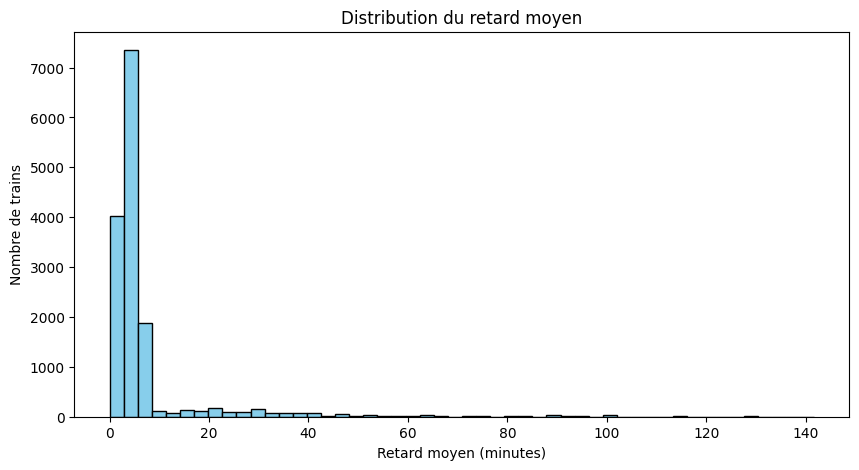

In [19]:
## Distribution of Retard moyen
plt.figure(figsize=(10,5))
plt.hist(sncf['retard moyen'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution du retard moyen")
plt.xlabel("Retard moyen (minutes)")
plt.ylabel("Nombre de trains")
plt.show()


The histogram shows a strongly right‑skewed distribution. The vast majority of trains have a very small average delay, close to 0 minutes, indicating that most services are either on time or experience only minor delays. As the delay increases, the number of affected trains decreases sharply. Large delays (beyond 15 or 30 minutes) are rare, which is consistent with operational reality, where major incidents remain exceptional. This distribution highlights an imbalanced dataset in which severe delays represent only a small minority of observations.

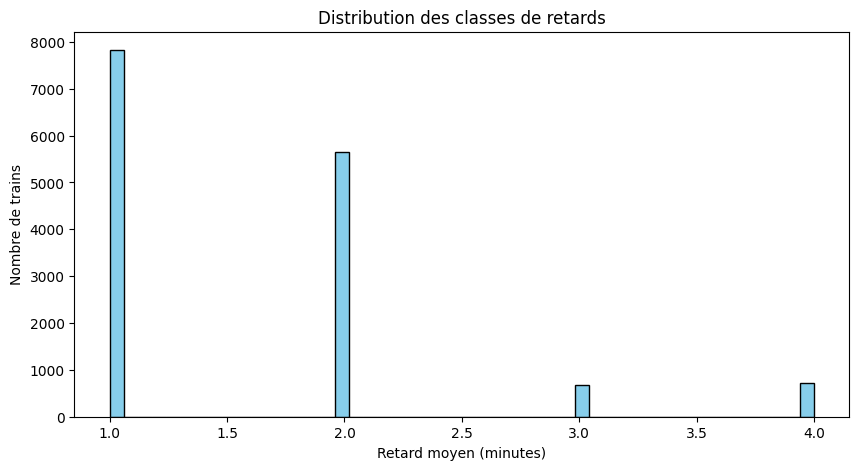

In [20]:
## Distribution de la classe de retard
plt.figure(figsize=(10,5))
plt.hist(sncf['classe_retard'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution des classes de retards")
plt.xlabel("Retard moyen (minutes)")
plt.ylabel("Nombre de trains")
plt.show()

As in the previous histogram, we can clearly see that trains with low delays corresponding to Class 1 (< 5 minutes) and Class 2 dominate the distribution. These two categories represent the vast majority of observations, while the higher delay classes are much less frequent. This confirms that the dataset is indeed imbalanced, with severe delays occurring only in a minority of cases.

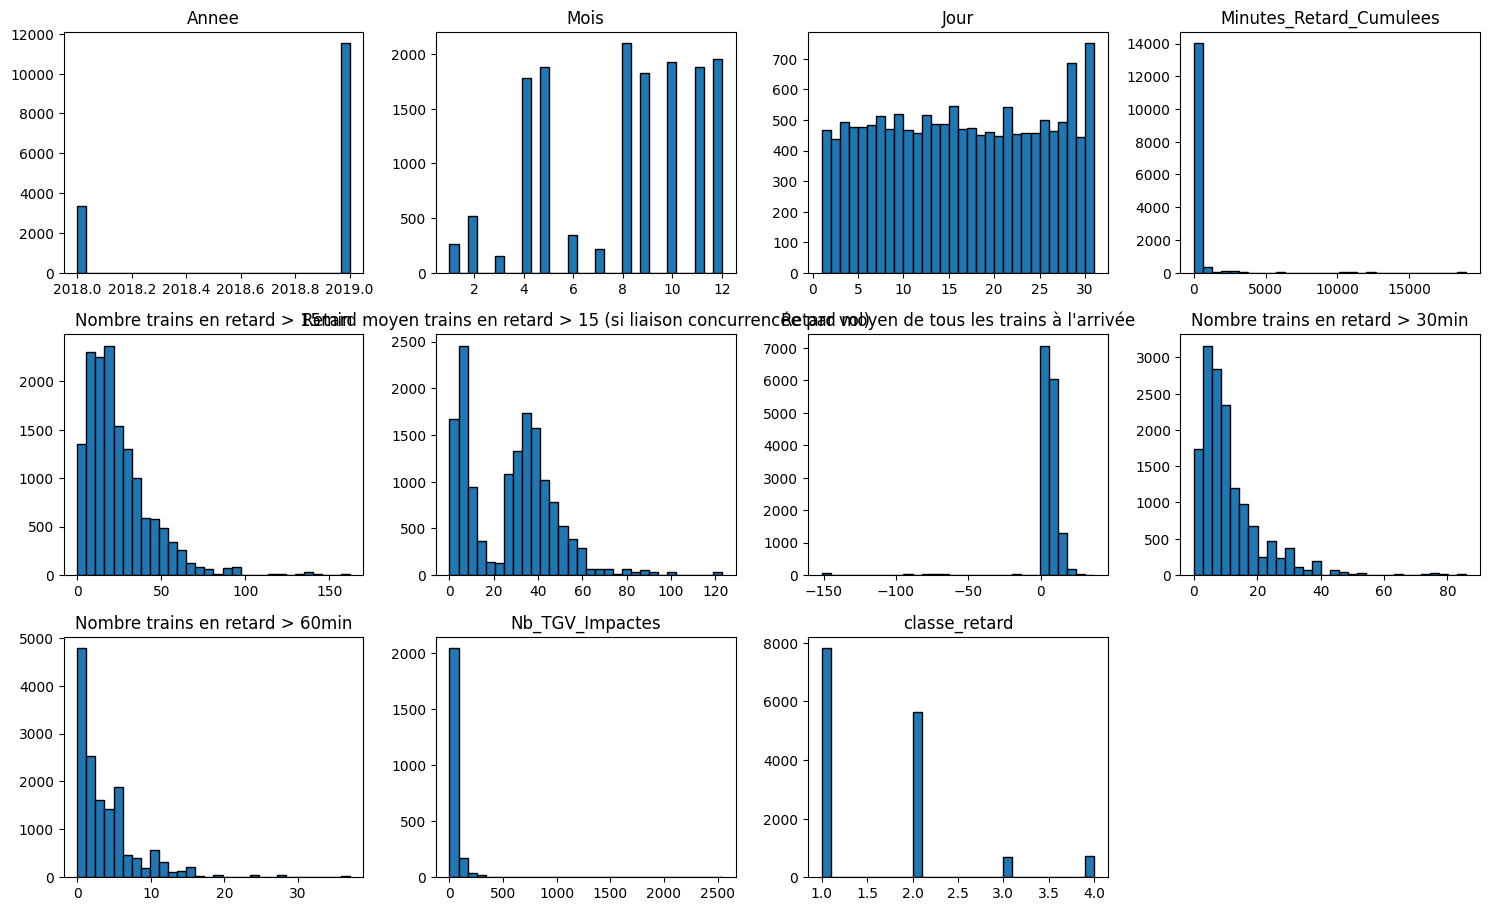

In [21]:
##  Distributions of the other numerical variables
num_cols = sncf.select_dtypes(include=['int64', 'float64']).columns.drop('retard moyen')

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    plt.hist(sncf[col].dropna(), bins=30, edgecolor='black')
    plt.title(col)
plt.tight_layout()
plt.show()

#### Boxplots

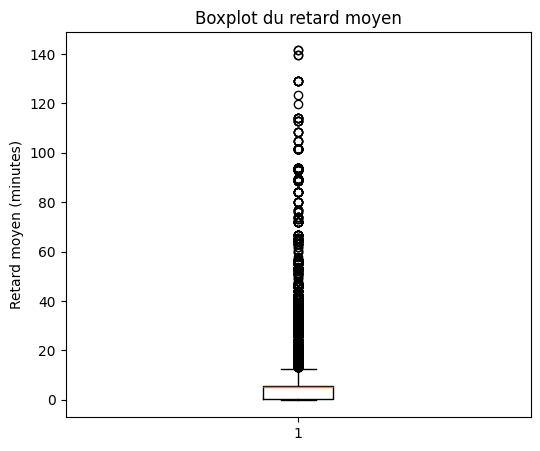

In [22]:
## boxplot of retard moyen
plt.figure(figsize=(6,5))
plt.boxplot(sncf['retard moyen'])
plt.title("Boxplot du retard moyen")
plt.ylabel("Retard moyen (minutes)")
plt.show()

The boxplot of the average delay shows a distribution highly concentrated around 0 minutes, with low dispersion and a strong skew toward positive values. This indicates that most trains experience only minor delays, while a limited number of observations appear as outliers corresponding to substantial delays, sometimes exceeding 100 minutes. The presence of a negative outlier reflects a few early arrivals, although such cases remain marginal. Overall, the plot confirms that large delays are rare and that the distribution is dominated by small delay values.

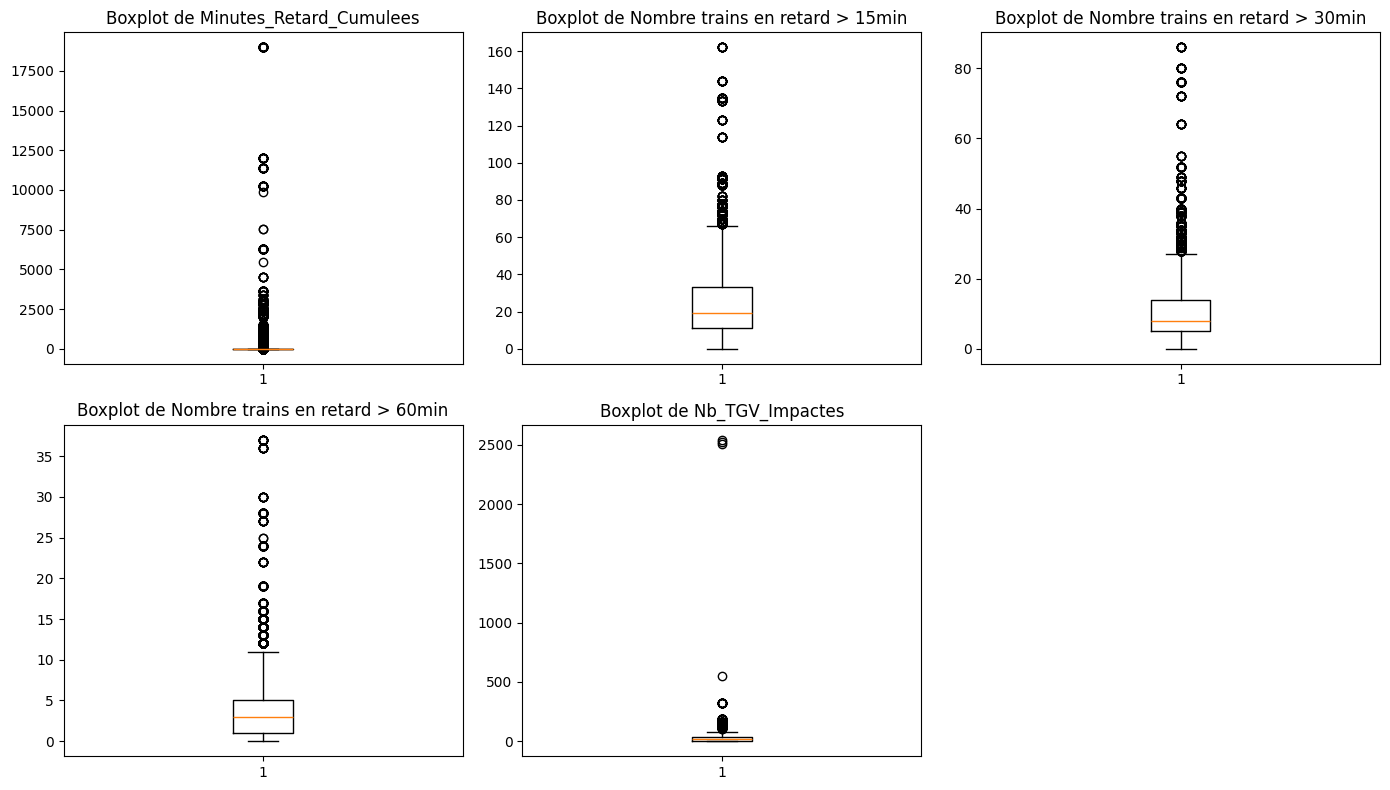

In [23]:
## boxplots of the other num values
num_vars = [
    'Minutes_Retard_Cumulees',
    'Nombre trains en retard > 15min',
    'Nombre trains en retard > 30min',
    'Nombre trains en retard > 60min',
    'Nb_TGV_Impactes'
]

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_vars, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(sncf[col].dropna())
    plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

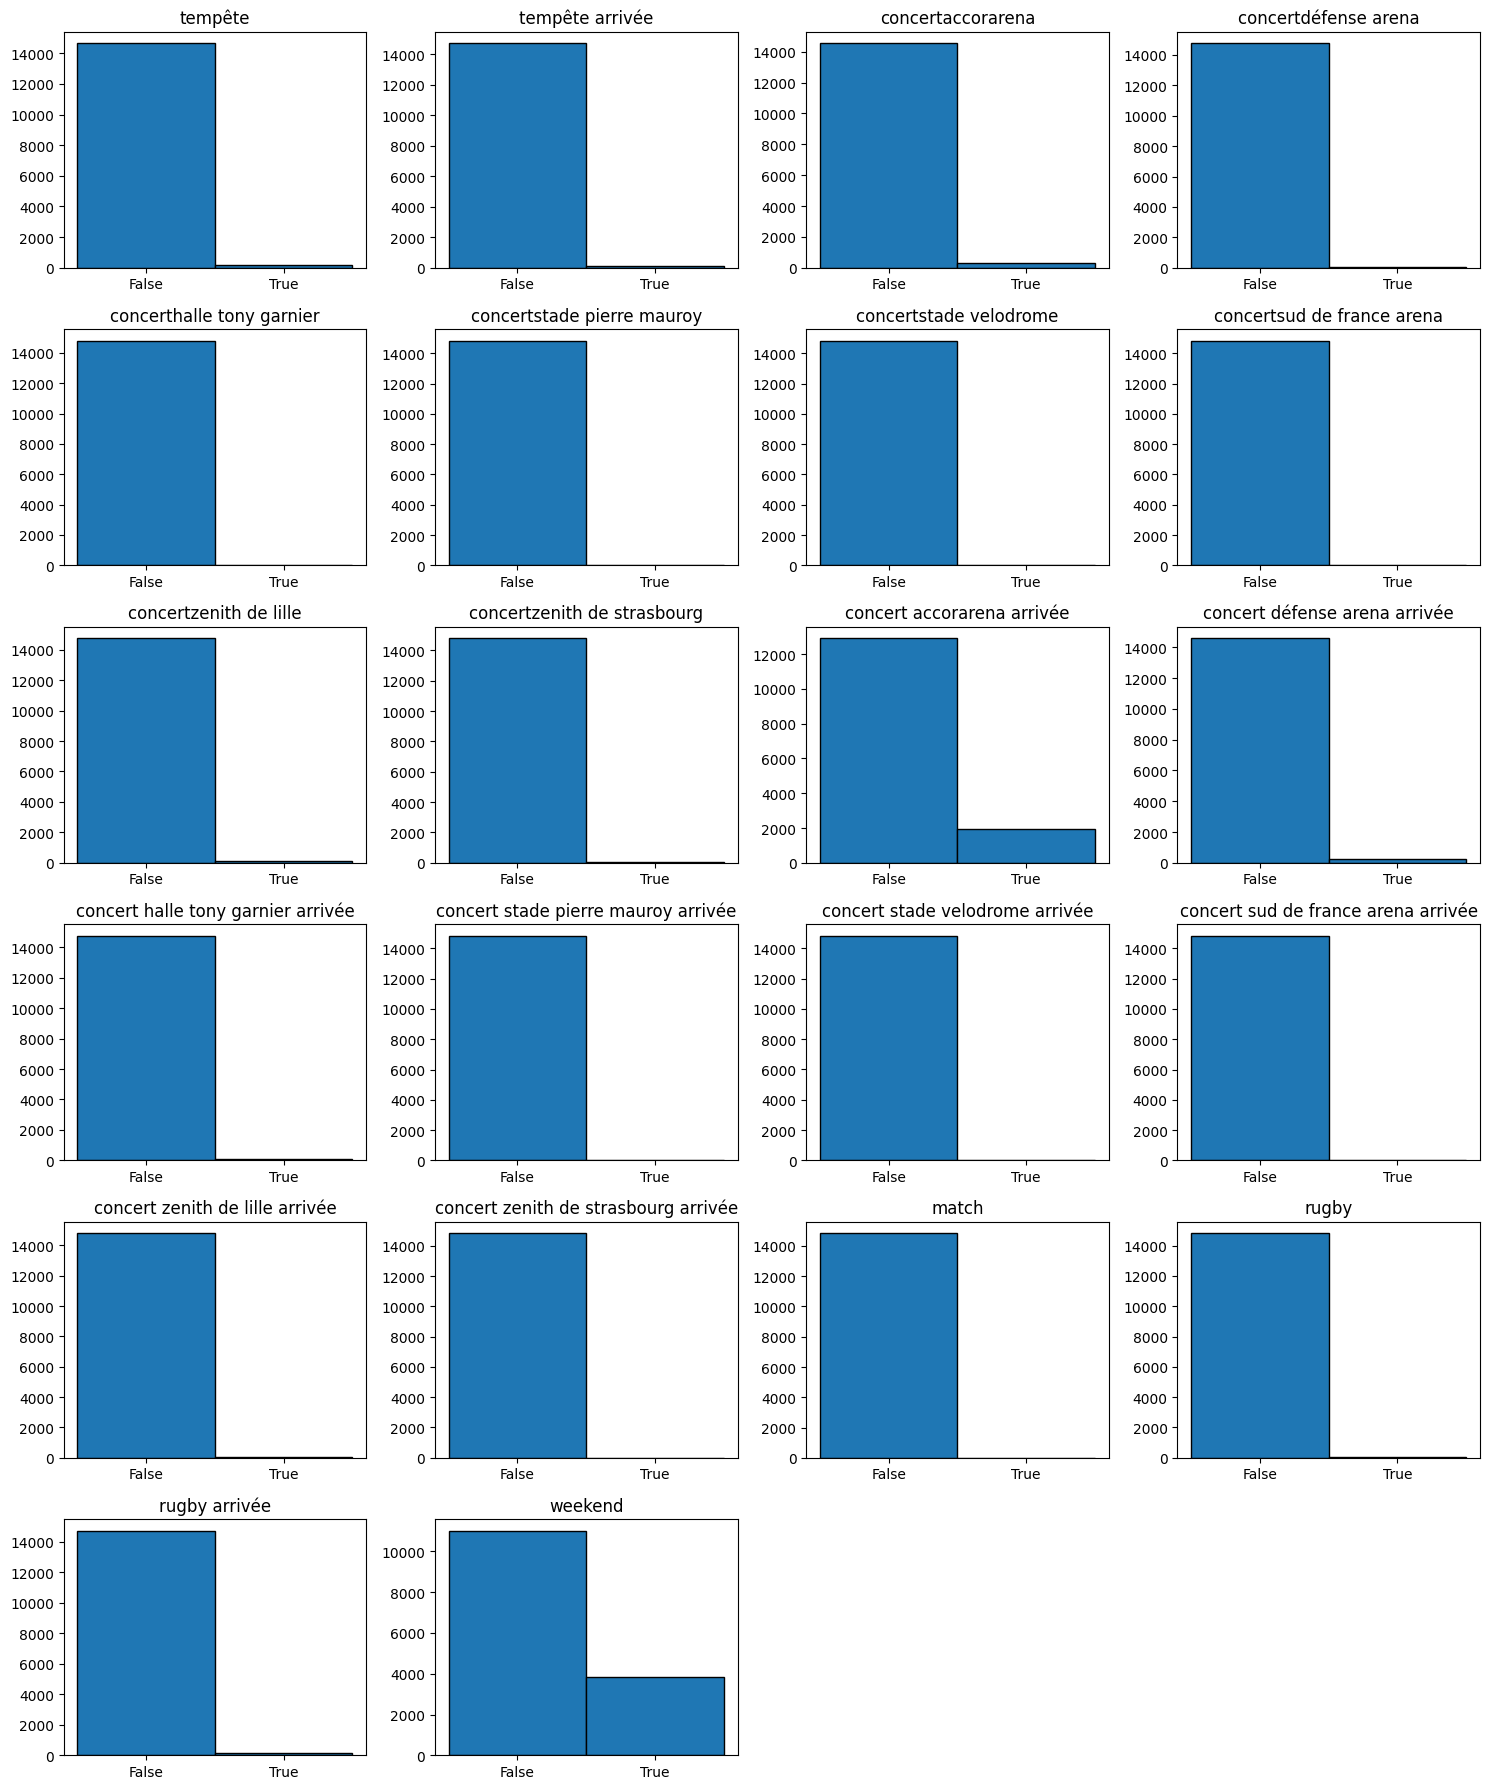

In [24]:
bool_cols = sncf.select_dtypes(include='bool').columns

n_cols = 4
n_rows = (len(bool_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(15, 3 * n_rows))
for i, col in enumerate(bool_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(sncf[col].astype(int), bins=[-0.5, 0.5, 1.5], edgecolor='black')
    plt.title(col)
    plt.xticks([0, 1], ['False', 'True'])
plt.tight_layout()
plt.show()


    

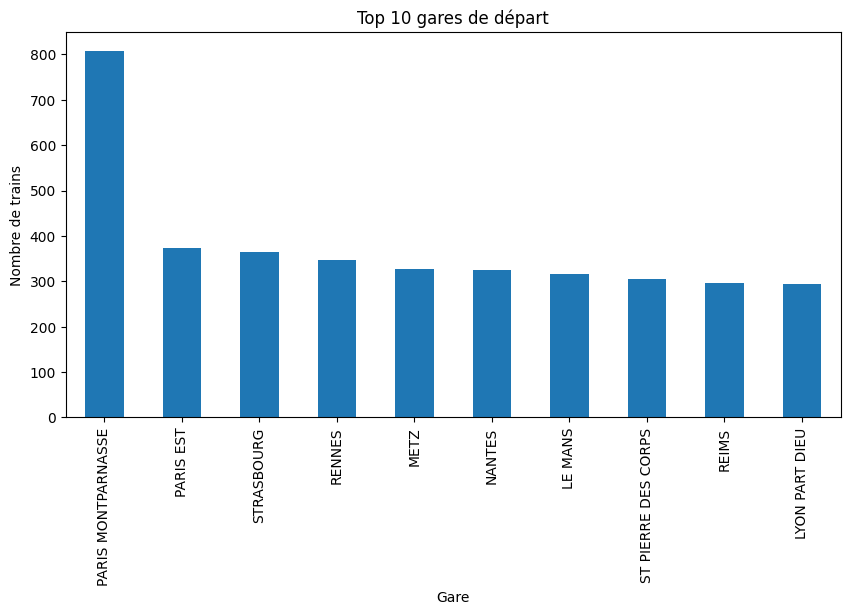

In [25]:
## topn 10 gares
sncf['Gare de départ'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 gares de départ")
plt.xlabel("Gare")
plt.ylabel("Nombre de trains")
plt.show()

## Bivariate analysis

<Figure size 800x500 with 0 Axes>

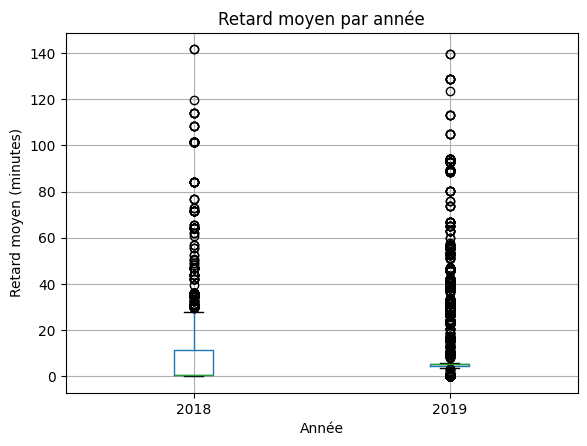

In [ ]:
plt.figure(figsize=(8,5))
sncf.boxplot(column='retard moyen', by='Annee')
plt.title("Retard moyen per year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Retard moyen (minutes)")
plt.show()

The average delay varies little between 2018 and 2019: both years display a similar distribution, with most trains experiencing only minor delays and a few extreme values corresponding to major incidents. The median is slightly higher in 2018, suggesting a marginal improvement in punctuality in 2019, although the difference remains modest.

<Figure size 1000x600 with 0 Axes>

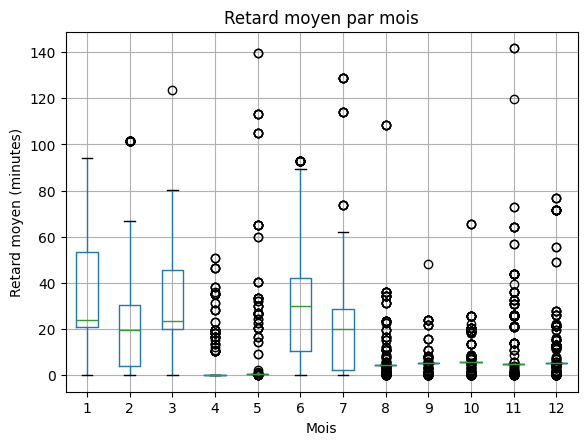

In [ ]:
plt.figure(figsize=(10,6))
sncf.boxplot(column='retard moyen', by='Mois')
plt.title("Retard moyen per month")
plt.suptitle("")  
plt.xlabel("Month")
plt.ylabel("Retard moyen (minutes)")
plt.show()

The variability of the average delay changes across the months, but no strong seasonality emerges. Most months show low delay levels, with a few significant outliers. Some months display a wider dispersion, which may correspond to isolated incidents such as severe weather, major events, or infrastructure works. Overall, delays remain relatively stable throughout the year.

<Figure size 1200x600 with 0 Axes>

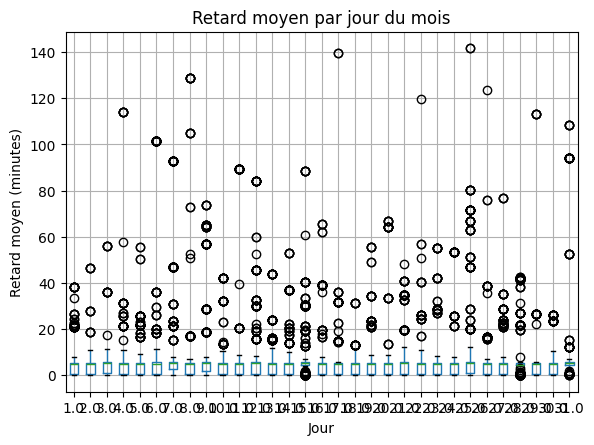

In [28]:
plt.figure(figsize=(12,6))
sncf.boxplot(column='retard moyen', by='Jour')
plt.title("Retard moyen par jour du mois")
plt.suptitle("")
plt.xlabel("Jour")
plt.ylabel("Retard moyen (minutes)")
plt.show()


The distribution of the average delay by day of the month is highly heterogeneous: each day shows a strong concentration of values around small delays, accompanied by several large outliers. There is no clear trend associated with the day number, indicating that delays do not follow any specific monthly cycle. The extreme values correspond to isolated events rather than a recurring pattern.

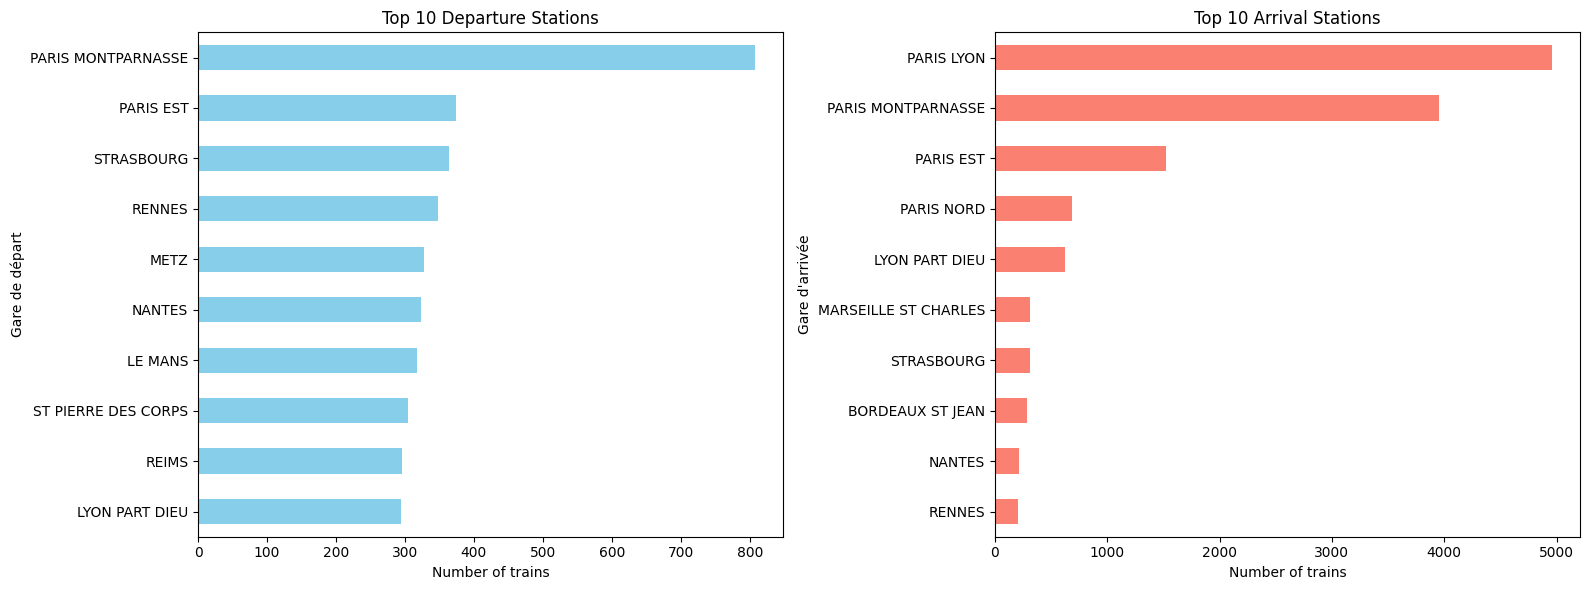

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Departure Stations
sncf['Gare de départ'].value_counts().head(10).plot(kind='barh', ax=ax[0], color='skyblue')
ax[0].set_title("Top 10 Departure Stations")
ax[0].invert_yaxis()
ax[0].set_xlabel('Number of trains')
# Top 10 Arrival Stations
sncf["Gare d'arrivée"].value_counts().head(10).plot(kind='barh', ax=ax[1], color='salmon')
ax[1].set_title("Top 10 Arrival Stations")
ax[1].invert_yaxis()
ax[1].set_xlabel('Number of trains')
plt.tight_layout()
plt.show()



We observe that Paris and Lyon, appear in both graphs which is coherent with the fact these are the stations of France’s biggest metropolis. The network's traffic is characterized by extreme centralization and regional imbalance. Paris-based stations (Montparnasse, Lyon, Est, Nord) dominate both arrivals and departures. 


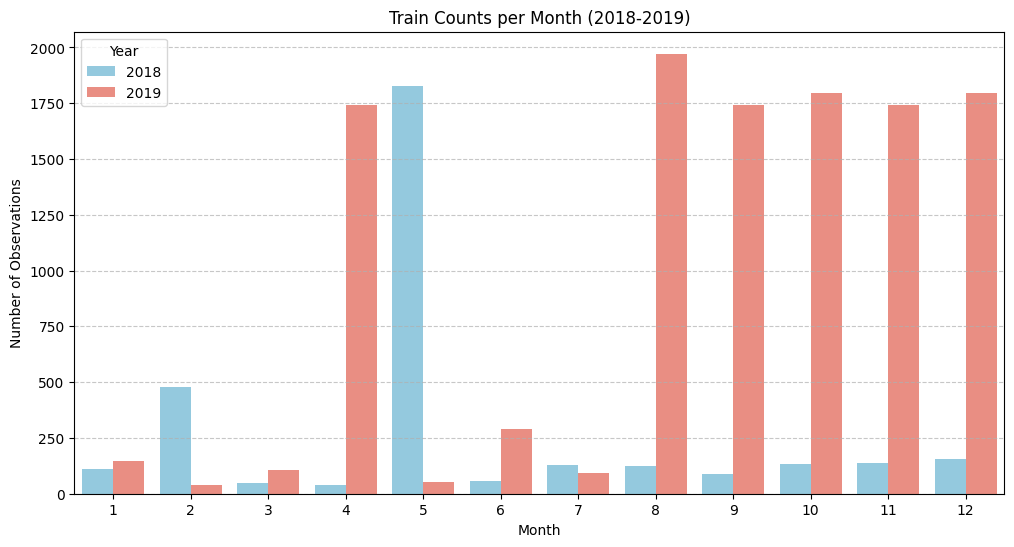

In [80]:

plt.figure(figsize=(12, 6))
sns.countplot(data=sncf, x='Mois', hue='Annee', palette=['skyblue', 'salmon'])
plt.title("Train Counts per Month (2018-2019)")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.legend(title='Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


2018 and 2019 are not represented as frequently. Furthermore, some months are underepresented, not the same for 2018 than 2019.

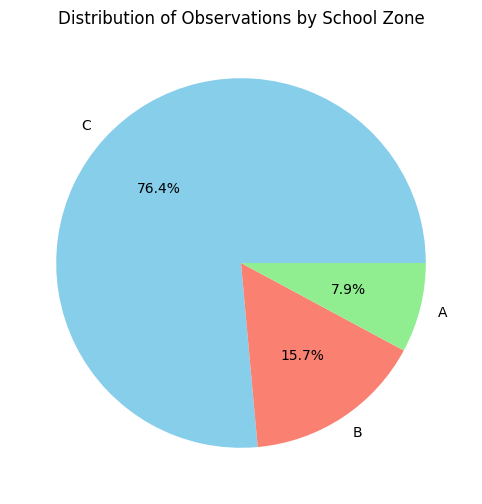

In [81]:
plt.figure(figsize=(8, 6))
sncf['zone'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon', 'lightgreen'])
plt.title("Distribution of Observations by School Zone")
plt.ylabel('') # Remove default label
plt.show()

There is a big disparity in data distribution by zone, coherent with the stations represented. The most common zone is zone C which is indeed Paris’ vacation zone. This is totally coherent with the rest of our data. 

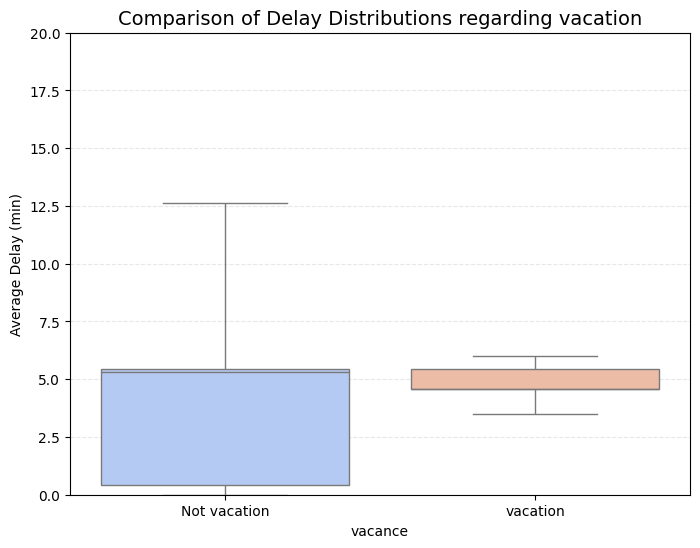

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=sncf, x='vacance', y='retard moyen', hue='vacance', 
            palette='coolwarm', showfliers=False, legend=False)

plt.title("Comparison of Delay Distributions regarding vacation", fontsize=14)
plt.xticks([0, 1], ['Not vacation', 'vacation'])
plt.ylabel("Average Delay (min)")

plt.ylim(0, 20) 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

the delay median both on vacation or not are about the same. However, the distribution of the delays vary quite a bit. On ordinary days, 75% of the trains have delays vary between about 0 and 6 minutes, whereas on vacation, the distribution of delays is less spread out, between 3 and 6 minutes of delay.

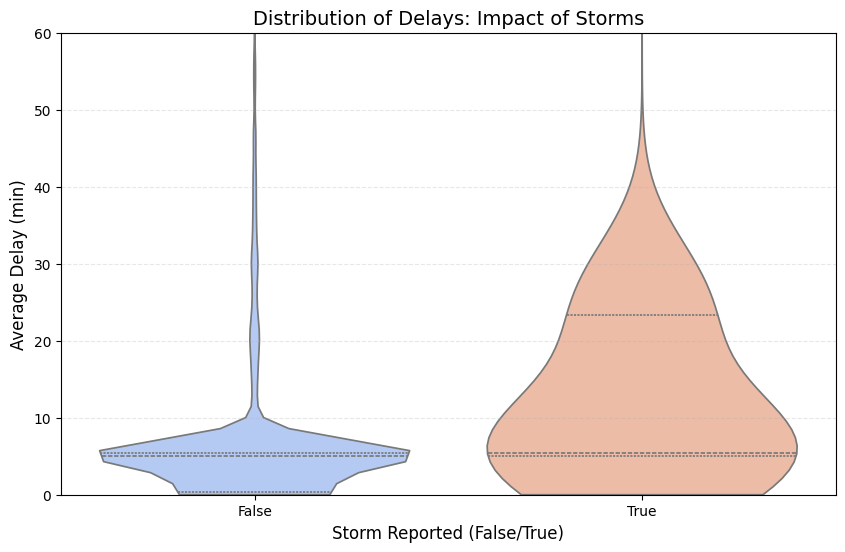

In [77]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=sncf, x='tempête', y='retard moyen', hue='tempête', 
               palette='coolwarm', inner="quartile", cut=0, legend=False)

plt.title("Distribution of Delays: Impact of Storms", fontsize=14)
plt.xlabel("Storm Reported (False/True)", fontsize=12)
plt.ylabel("Average Delay (min)", fontsize=12)

#Zoom in on the 0-60 min range so the quartiles become visible
plt.ylim(0, 60) 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

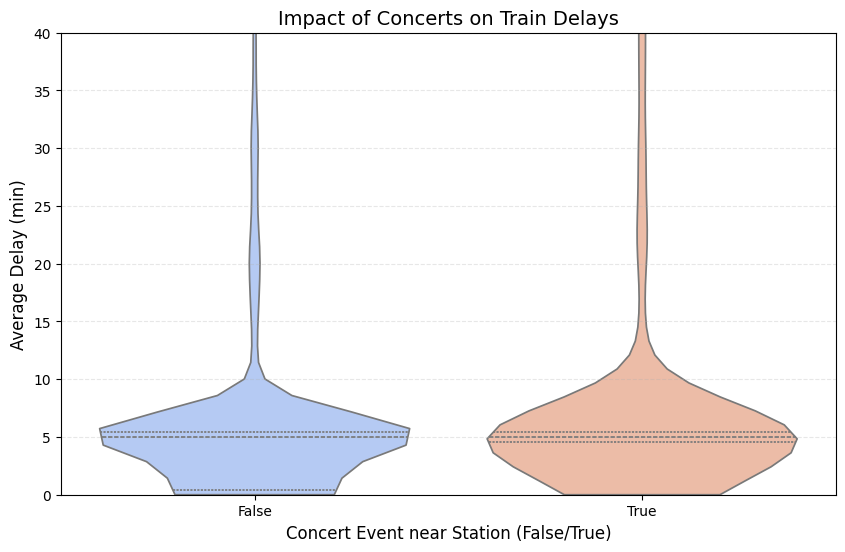

In [76]:
# List all columns that contain 'concert'
concert_cols = [col for col in sncf.columns if 'concert' in col.lower()]

# Create the grouped column: True if any concert column is 1/True
sncf['has_concert'] = sncf[concert_cols].any(axis=1)

# Visualization
plt.figure(figsize=(10, 6))

sns.violinplot(data=sncf, x='has_concert', y='retard moyen', hue='has_concert',
               palette='coolwarm', inner="quartile", cut=0, legend=False)

plt.title("Impact of Concerts on Train Delays", fontsize=14)
plt.xlabel("Concert Event near Station (False/True)", fontsize=12)
plt.ylabel("Average Delay (min)", fontsize=12)

#Zooming to 0-40 to see the distribution 'body' clearly
plt.ylim(0, 40)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Environmental factors show a pronounced impact on reliability compared to social events. The presence of a storm shifts the entire distribution upward the "True" category shows a higher median delay, a way higher 75\% quartile and a much wider "belly" in the violin plot between  20–40 minutes.
Conversely, concert events near stations have a smaller effect on average delays. The distribution for "True" and "False" remains almost identical, with both showing a heavy concentration around the 5-minute mark, suggesting that the rail network handles event-based surges in passenger volume without significant operational lag. However, we do notice a slightly larger tail in the "True" plot and a significantly giher 25\% percentile.

#### Correlation matrix

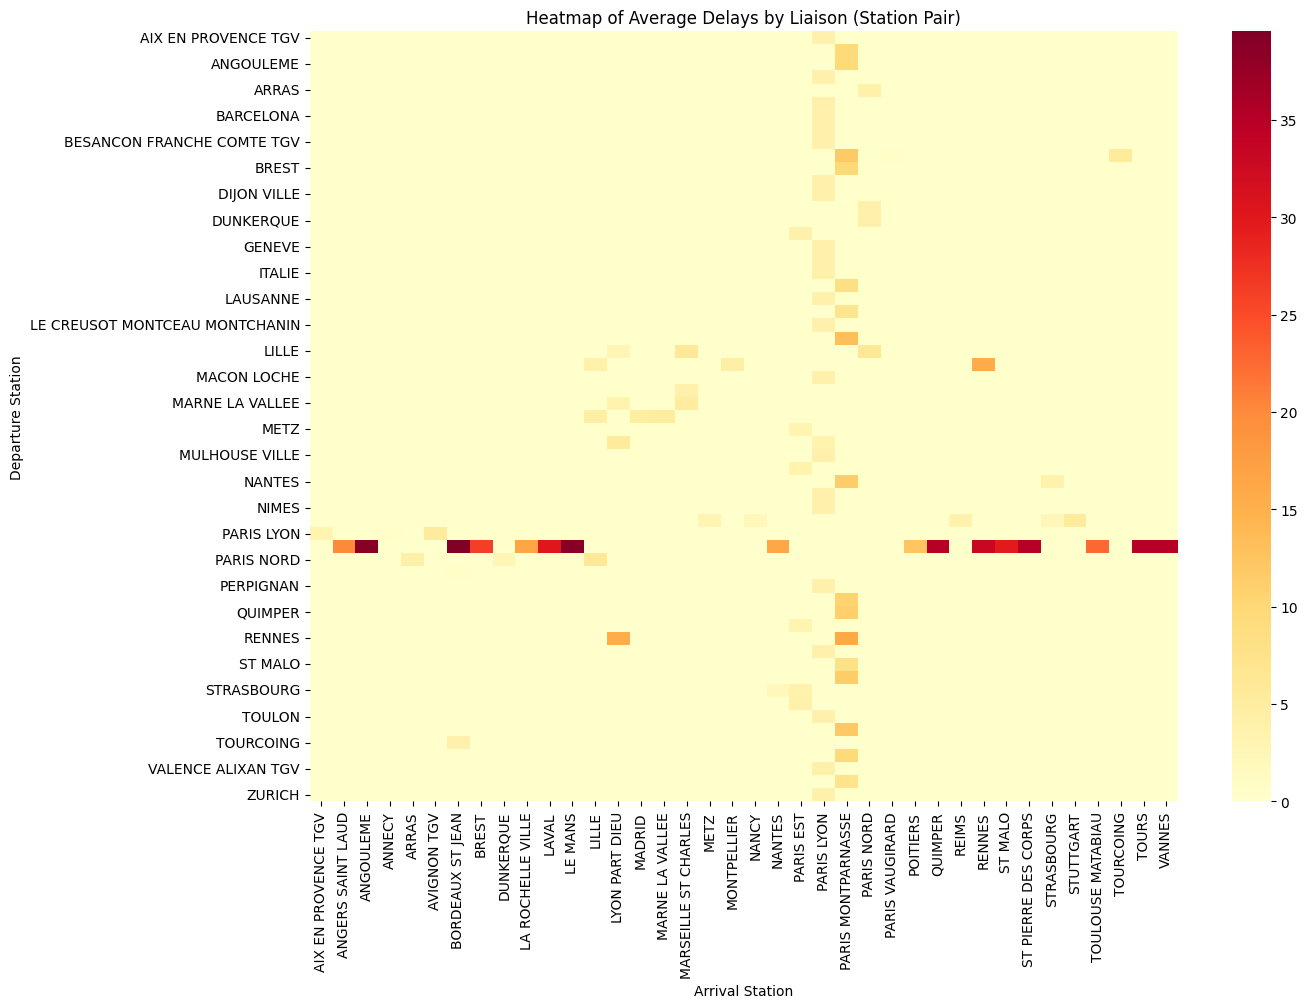

In [78]:
# Create a pivot table for the heatmap
pivot_delays = sncf.pivot_table(index='Gare de départ', 
                               columns="Gare d'arrivée", 
                               values='retard moyen', 
                               aggfunc='mean').fillna(0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_delays, cmap='YlOrRd')
plt.title("Heatmap of Average Delays by Liaison (Station Pair)")
plt.xlabel("Arrival Station")
plt.ylabel("Departure Station")
plt.show()

The heatmap reveals that delays are not uniform across the network but are concentrated on specific corridors. The most intense delays, indicated by dark red, are predominantly associated with Paris Lyon as a departure point, specifically on routes toward Angouleme, Bordeaux, and Le Mans. Regarding the arrivals, Paris Montparnasse seems to be a major hub for delays. While most station pairs maintain a low average delay, light yellow, the Paris hub serves as a primary source of significant temporal deviations, creating a clear disparity between regional liaisons and those connecting to the capital.

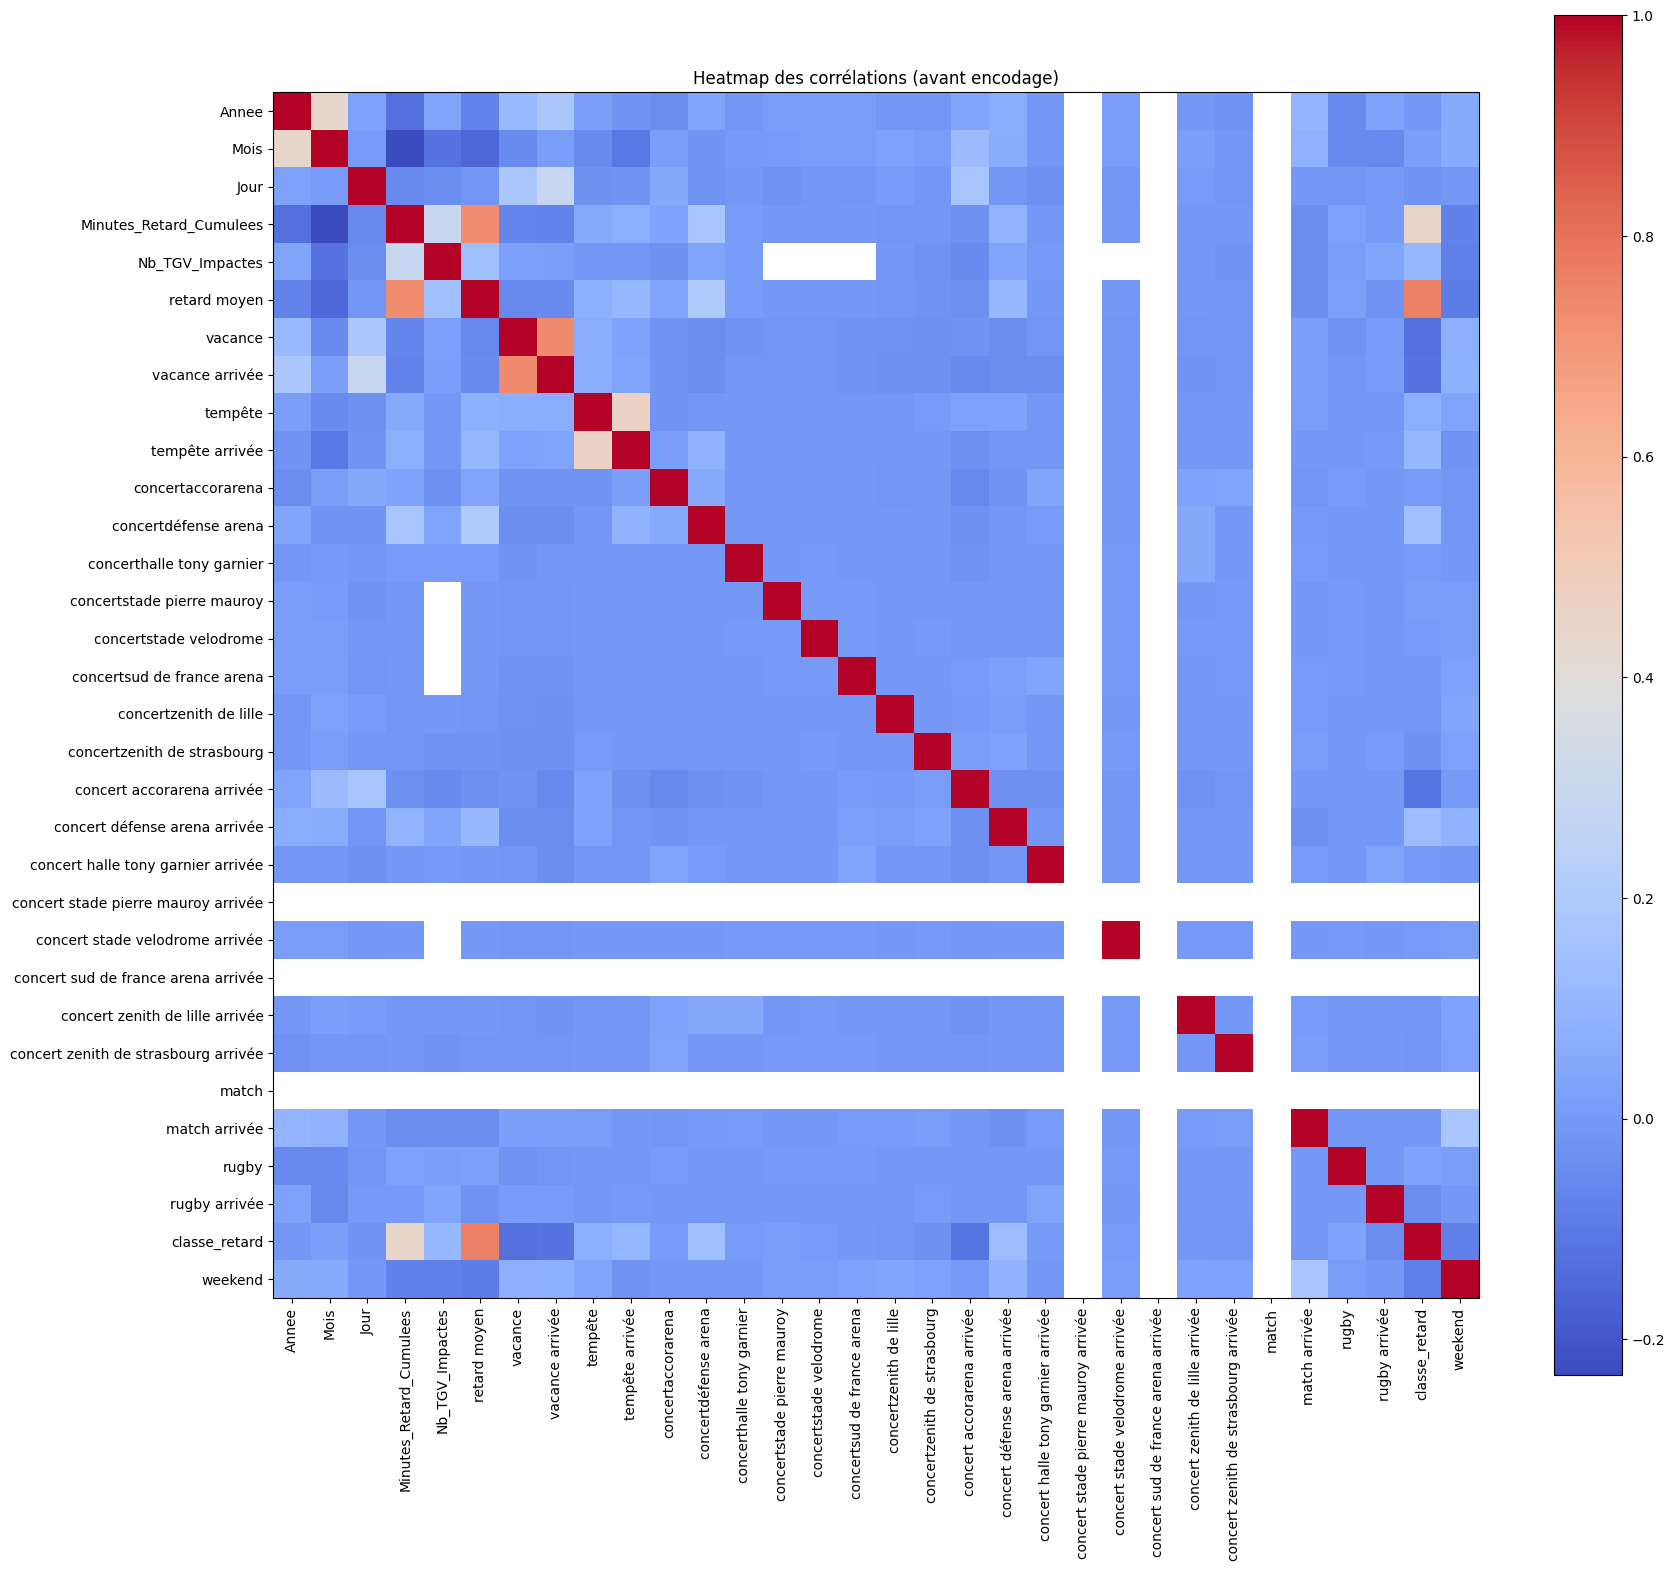

In [30]:
## correlation

cols_corr = [
    'Annee', 'Mois', 'Jour',
    'Minutes_Retard_Cumulees', 'Nb_TGV_Impactes', 'retard moyen',
    'vacance', 'vacance arrivée',
    'tempête', 'tempête arrivée',
    'concertaccorarena', 'concertdéfense arena',
    'concerthalle tony garnier', 'concertstade pierre mauroy',
    'concertstade velodrome', 'concertsud de france arena',
    'concertzenith de lille', 'concertzenith de strasbourg',
    'concert accorarena arrivée', 'concert défense arena arrivée',
    'concert halle tony garnier arrivée',
    'concert stade pierre mauroy arrivée',
    'concert stade velodrome arrivée',
    'concert sud de france arena arrivée',
    'concert zenith de lille arrivée',
    'concert zenith de strasbourg arrivée',
    'match', 'match arrivée',
    'rugby', 'rugby arrivée',
    'classe_retard',
    'weekend'
]

# correlation matrix
corr = sncf[cols_corr].corr()


plt.figure(figsize=(18, 16))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(cols_corr)), cols_corr, rotation=90)
plt.yticks(range(len(cols_corr)), cols_corr)

plt.title("Heatmap des corrélations (avant encodage)")
plt.tight_layout()
plt.show()


The heatmap shows that correlations between variables are generally weak, meaning that events (concerts, matches, storms, holidays) are not strongly related to each other or to delays. The only notable correlations appear between the pairs “event” and “event_arrival,” which is expected since they describe the same phenomenon. Temporal variables (year, month, day) do not directly explain delays. The variable classe_retard is only weakly correlated with the others, confirming that delay prediction is a complex problem influenced by rare and scattered factors.

## 3.Machine Learning

In [18]:
cat_cols = [
    'Gare de départ',
    'Gare d\'arrivée',
    'zone'
]

In [19]:
num_cols = [
    'Annee', 'Mois', 'Jour',
    'weekend', 'vacance', 'vacance arrivée',
    'tempête', 'tempête arrivée',
    'match', 'match arrivée',
    'rugby', 'rugby arrivée',
    'concertaccorarena', 'concertdéfense arena',
    'concerthalle tony garnier', 'concertstade pierre mauroy',
    'concertstade velodrome', 'concertsud de france arena',
    'concertzenith de lille', 'concertzenith de strasbourg',
    'concert accorarena arrivée', 'concert défense arena arrivée',
    'concert halle tony garnier arrivée',
    'concert stade pierre mauroy arrivée',
    'concert stade velodrome arrivée',
    'concert sud de france arena arrivée',
    'concert zenith de lille arrivée',
    'concert zenith de strasbourg arrivée'
]


In [20]:
X = sncf[cat_cols + num_cols]
y_class = sncf['classe_retard']      # target classification
y_reg = sncf['retard moyen']         # target regression

In [21]:
#preprocess
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

### Classification

In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [23]:
# classifcation
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=200, random_state=42)
}

#### Logistic regression

In [37]:
# Compute balanced class weights after train/test split
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), cw))

# Pipeline with balanced class weights
logreg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight=class_weight_dict))
])

In [38]:
# Stratified CV to handle class imbalance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(logreg, X, y_class, cv=skf, scoring='accuracy')

print('Cross-validation accuracy scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean())
print('Macro F1 (CV):', cross_val_score(logreg, X, y_class, cv=skf, scoring='f1_macro').mean())

Cross-validation accuracy scores: [0.74924268 0.76371592 0.75732077 0.76060606 0.77373737]
Mean CV accuracy: 0.760924560311972
Macro F1 (CV): 0.6275010629699151


The logistic regression model achieves a mean cross‑validated accuracy of approximately 0.76, indicating stable performance across folds. The macro‑averaged F1‑score of 0.63 reflects the difficulty of predicting minority classes, but overall the model generalizes well. These results confirm that logistic regression provides a solid baseline classifier for this imbalanced multi‑class problem.

In [39]:
# Train
logreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [40]:
# Predict
y_pred = logreg.predict(X_test)

In [41]:
# Metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall (weighted):', recall_score(y_test, y_pred, average='weighted'))
print('F1 (weighted):', f1_score(y_test, y_pred, average='weighted'))
print('F1 (macro)   :', f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.7721305957590037
Recall (weighted): 0.7721305957590037
F1 (weighted): 0.7826228813748364
F1 (macro)   : 0.6316182294853883


On the test set, the model reaches an accuracy of 0.77 and a weighted F1‑score of 0.78. These values are consistent with the cross‑validation results, showing that the model performs reliably on unseen data. The macro‑averaged F1‑score of 0.63 highlights the imbalance between classes and the greater difficulty of predicting rare, high‑delay events.

In [42]:
# results
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.95      0.70      0.80      1565
           2       0.77      0.92      0.84      1129
           3       0.32      0.61      0.42       135
           4       0.39      0.58      0.47       142

    accuracy                           0.77      2971
   macro avg       0.61      0.70      0.63      2971
weighted avg       0.82      0.77      0.78      2971



Class 1 : Low delays  

This class is predicted with high precision (0.95) and acceptable recall (0.70). The model correctly identifies most low‑delay cases but occasionally confuses them with class 2, which is expected given their proximity.

Class 2 : Moderate delays  

This is the best‑predicted class, with a recall of 0.92 and an F1‑score of 0.84. The model captures the majority of moderate‑delay events, reflecting the strong representation of this class in the dataset.

Class 3 : Significant delays  
Performance decreases for this minority class. The recall of 0.61 shows that the model retrieves more than half of the true cases, but the precision remains low due to confusion with class 4.

Class 4 : Severe delays 

Similarly, class 4 suffers from limited precision (0.39) and moderate recall (0.58). The model struggles to distinguish between classes 3 and 4, which share similar characteristics and are under‑represented.

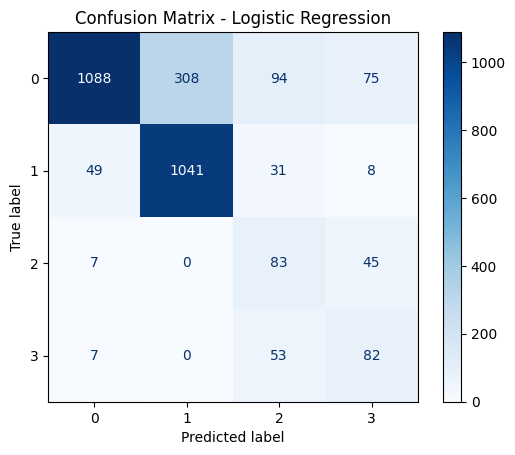

In [43]:
# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix reveals strong separation between classes 1 and 2, which dominate the dataset and exhibit clearer patterns. In contrast, classes 3 and 4 show substantial overlap, leading to frequent misclassifications between them. This behavior is typical in imbalanced datasets where rare classes have limited variability and are difficult to distinguish using linear decision boundaries.

Overall, logistic regression provides a robust baseline model, performing well on the majority classes and capturing the main structure of the data. However, the model struggles with the rare high‑delay classes, which exhibit overlapping distributions and limited sample sizes. These results highlight the need for more flexible models or rebalancing strategies to improve the prediction of severe delay events.

#### Linear Discriminant Analysis 'LDA'

In [44]:
#pipeline
lda = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearDiscriminantAnalysis())
])

In [45]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lda, X, y_class, cv=skf, scoring='accuracy')

print('Cross-validation accuracy scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean())
print('Macro F1 (CV):', cross_val_score(lda, X, y_class, cv=skf, scoring='f1_macro').mean())

Cross-validation accuracy scores: [0.77078425 0.78424773 0.78290138 0.78686869 0.79292929]
Mean CV accuracy: 0.7835462671140894
Macro F1 (CV): 0.5963063230363322


The Linear Discriminant Analysis model achieves a mean cross‑validated accuracy of 0.78, which is slightly higher than logistic regression. This indicates that LDA captures the linear structure of the data more effectively. However, the macro‑averaged F1‑score remains moderate (0.60), reflecting the persistent difficulty of predicting minority classes. Overall, LDA provides a strong and stable baseline with improved accuracy compared to logistic regression.

In [46]:
# Train
lda.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [47]:
# Predict
y_pred = lda.predict(X_test)

In [48]:
# Metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall (weighted):', recall_score(y_test, y_pred, average='weighted'))
print('F1 (weighted):', f1_score(y_test, y_pred, average='weighted'))
print('F1 (macro)   :', f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.7953550992931673
Recall (weighted): 0.7953550992931673
F1 (weighted): 0.790301057840674
F1 (macro)   : 0.6267370289288513


On the test set, LDA reaches an accuracy of 0.80 and a weighted F1‑score of 0.79, confirming its good generalization ability. The macro‑averaged F1‑score of 0.63 shows that performance remains uneven across classes, with minority classes still challenging to predict. These results are consistent with the cross‑validation metrics and highlight LDA’s robustness on this dataset.

In [49]:
# results
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.86      0.80      0.83      1565
           2       0.77      0.90      0.83      1129
           3       0.43      0.36      0.39       135
           4       0.61      0.37      0.46       142

    accuracy                           0.80      2971
   macro avg       0.67      0.61      0.63      2971
weighted avg       0.79      0.80      0.79      2971



Class 1 : Low delays  

LDA achieves strong performance on this class, with a recall of 0.80 and an F1‑score of 0.83. The model correctly identifies most low‑delay cases, although some confusion with class 2 persists.

Class 2 : Moderate delays  

This class is also well predicted, with a recall of 0.90 and an F1‑score of 0.83. LDA effectively captures the dominant patterns associated with moderate delays.

Class 3 : Significant delays 

Performance decreases for this minority class. The recall drops to 0.36, and the F1‑score to 0.39, indicating that LDA struggles to separate class 3 from the neighboring classes, especially class 4.

Class 4 : Severe delays  

Class 4 shows a recall of 0.37 and an F1‑score of 0.46. While precision is higher than for class 3, the model still confuses many severe delays with class 3, reflecting the overlap between these two categories.

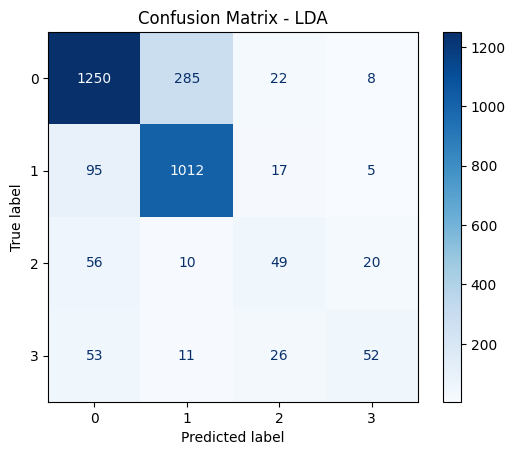

In [50]:
# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues")
plt.title("Confusion Matrix - LDA")
plt.show()

The confusion matrix shows strong diagonal values for classes 1 and 2, confirming that LDA performs well on the majority classes. However, classes 3 and 4 exhibit substantial misclassification, with many instances predicted as each other or as class 2. This pattern indicates that the linear boundaries learned by LDA are insufficient to fully separate the high‑delay classes, which are both rare and highly overlapping in feature space.

Overall, LDA outperforms logistic regression in terms of accuracy while maintaining similar macro‑level performance. The model handles the dominant classes effectively but continues to struggle with the minority high‑delay classes, which remain difficult to distinguish due to their limited representation and overlapping characteristics. LDA therefore provides a strong linear baseline, but more flexible models may be required to improve predictions for severe delay events.

#### Random Forest (Decision trees)

In [51]:
#pipeline with balanced class weights
rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42,
                                      class_weight=class_weight_dict))
])

In [52]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y_class, cv=skf, scoring='accuracy')

print('Cross-validation accuracy scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean())
print('Macro F1 (CV):', cross_val_score(rf, X, y_class, cv=skf, scoring='f1_macro').mean())

Cross-validation accuracy scores: [0.95018512 0.94883877 0.94681925 0.94343434 0.94242424]
Mean CV accuracy: 0.9463403472625955
Macro F1 (CV): 0.8054257556853408


The Random Forest model achieves an excellent mean cross‑validated accuracy of 0.95, far surpassing the linear models. The macro‑averaged F1‑score of 0.81 confirms that the model performs well across all classes, including the minority ones. These results indicate that Random Forest captures complex nonlinear relationships in the data and handles class imbalance more effectively than linear classifiers.

In [53]:
# Train
rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [54]:
# Predict
y_pred = rf.predict(X_test)

In [55]:
# Metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall (weighted):', recall_score(y_test, y_pred, average='weighted'))
print('F1 (weighted):', f1_score(y_test, y_pred, average='weighted'))
print('F1 (macro)   :', f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.9505217098619994
Recall (weighted): 0.9505217098619994
F1 (weighted): 0.950380707226127
F1 (macro)   : 0.8193194396443365


Random Forest captures non‑linear relationships and handles interactions between features. This is the best model of instance. On the test set, it reaches an accuracy of 0.95 and a weighted F1‑score of 0.95, demonstrating outstanding generalization. The macro‑averaged F1‑score of 0.82 shows a substantial improvement over logistic regression and LDA, particularly for the high‑delay classes. The consistency between cross‑validation and test performance confirms the robustness of the model.

In [56]:
# results
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.98      0.99      0.99      1565
           2       0.98      0.96      0.97      1129
           3       0.64      0.66      0.65       135
           4       0.68      0.65      0.67       142

    accuracy                           0.95      2971
   macro avg       0.82      0.82      0.82      2971
weighted avg       0.95      0.95      0.95      2971



Class 1 : Low delays  

The model achieves near‑perfect performance, with a recall of 0.99 and an F1‑score of 0.99. Random Forest distinguishes this class extremely well, with almost no misclassifications.

Class 2 : Moderate delays 

Class 2 is also predicted with very high accuracy (F1‑score of 0.97). The model captures the structure of this class with remarkable precision and recall.

Class 3 : Significant delays  

Performance improves substantially compared to linear models. With a recall of 0.66 and an F1‑score of 0.65, the model correctly identifies two‑thirds of significant delay events — a notable gain over LDA and logistic regression.

Class 4 : Severe delays  

Class 4 also benefits from the nonlinear modeling capacity of Random Forest. The recall reaches 0.65 and the F1‑score 0.67, making this the best performance obtained so far for the most severe delay category.

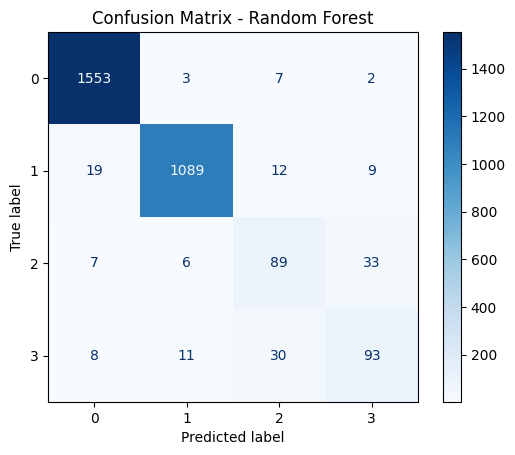

In [57]:
# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

The confusion matrix shows extremely strong diagonal values for classes 1 and 2, confirming the model’s excellent ability to classify the majority classes. Importantly, Random Forest significantly reduces confusion between classes 3 and 4 compared to linear models. Although some overlap remains, the model captures the structure of high‑delay events far more effectively, demonstrating its ability to model nonlinear boundaries and complex interactions.

Random Forest clearly outperforms all previously tested models. It achieves high accuracy, strong macro‑level performance, and substantial improvements on the minority high‑delay classes. The model successfully captures nonlinear relationships and interactions between features, making it particularly well suited for this classification task. These results suggest that Random Forest is a highly effective model for predicting train delay categories, especially when severe delays are of interest.

#### K-Nearest neighbours 'KNN'

 **Tuning the hyperameter K**

In [58]:
k_values = range(1, 51)   # test k from 1 to 50
cv_scores = []

In [59]:
for k in k_values:
    knn = Pipeline([
        ("preprocess", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(knn, X, y_class, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

In [60]:

# results
for k, score in zip(k_values, cv_scores):
    print(f"k = {k}, Mean CV Accuracy = {score:.4f}")

k = 1, Mean CV Accuracy = 0.6088
k = 2, Mean CV Accuracy = 0.6191
k = 3, Mean CV Accuracy = 0.6420
k = 4, Mean CV Accuracy = 0.6386
k = 5, Mean CV Accuracy = 0.6797
k = 6, Mean CV Accuracy = 0.6790
k = 7, Mean CV Accuracy = 0.6883
k = 8, Mean CV Accuracy = 0.6793
k = 9, Mean CV Accuracy = 0.6883
k = 10, Mean CV Accuracy = 0.6836
k = 11, Mean CV Accuracy = 0.7046
k = 12, Mean CV Accuracy = 0.7001
k = 13, Mean CV Accuracy = 0.7111
k = 14, Mean CV Accuracy = 0.7040
k = 15, Mean CV Accuracy = 0.7126
k = 16, Mean CV Accuracy = 0.7120
k = 17, Mean CV Accuracy = 0.7177
k = 18, Mean CV Accuracy = 0.7159
k = 19, Mean CV Accuracy = 0.7217
k = 20, Mean CV Accuracy = 0.7222
k = 21, Mean CV Accuracy = 0.7239
k = 22, Mean CV Accuracy = 0.7231
k = 23, Mean CV Accuracy = 0.7272
k = 24, Mean CV Accuracy = 0.7248
k = 25, Mean CV Accuracy = 0.7213
k = 26, Mean CV Accuracy = 0.7238
k = 27, Mean CV Accuracy = 0.7239
k = 28, Mean CV Accuracy = 0.7254
k = 29, Mean CV Accuracy = 0.7259
k = 30, Mean CV Accurac

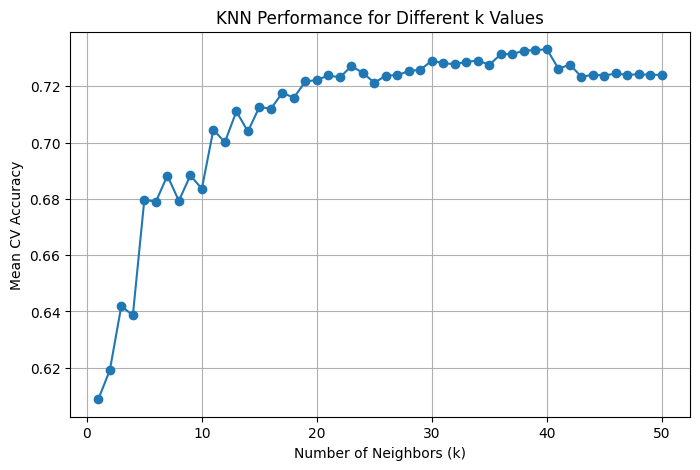

In [61]:
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN Performance for Different k Values")
plt.grid(True)
plt.show()

To determine the optimal number of neighbors, KNN was evaluated using 5‑fold cross‑validation for values of k ranging from 1 to 50. The model shows a clear upward trend: performance increases from 0.60 at k = 1 to approximately 0.73 for larger values of k. The best cross-validation accuracy is obtained at k = 40, with a mean accuracy of 0.73 (rounded down).

The tuning curve indicates that small values of k lead to high variance and poor generalization, while larger values stabilize the model and improve performance. Beyond k ≈ 40, the accuracy plateaus, suggesting diminishing returns.

The optimal value k = 40 is therefore selected for the final KNN model.

**Train and evaluation on the best K**

In [62]:
best_k = k_values[np.argmax(cv_scores)]
print("Best k =", best_k)

Best k = 40


In [63]:
# final pipline
knn = Pipeline([
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

In [64]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn, X, y_class, cv=skf, scoring='accuracy')

print('Cross-validation accuracy scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean())
print('Macro F1 (CV):', cross_val_score(knn, X, y_class, cv=skf, scoring='f1_macro').mean())

Cross-validation accuracy scores: [0.84786267 0.85526759 0.85089196 0.85656566 0.85622896]
Mean CV accuracy: 0.8533633655074248
Macro F1 (CV): 0.6981705496805806


The K‑Nearest Neighbors model achieves a mean cross‑validated accuracy of 0.85, which is significantly higher than the linear models but below the performance of Random Forest. The macro‑averaged F1‑score of 0.70 indicates that KNN handles the minority classes better than logistic regression and LDA, although its performance remains sensitive to class imbalance and feature scaling. Overall, KNN provides a strong nonlinear baseline with solid generalization.

In [65]:
# Train
knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [66]:
# Predict
y_pred = knn.predict(X_test)

In [67]:
# Metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall (weighted):', recall_score(y_test, y_pred, average='weighted'))
print('F1 (weighted):', f1_score(y_test, y_pred, average='weighted'))
print('F1 (macro)   :', f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.8593066307640526
Recall (weighted): 0.8593066307640526
F1 (weighted): 0.853628445000693
F1 (macro)   : 0.7156029986962191


On the test set, KNN reaches an accuracy of 0.86 and a weighted F1‑score of 0.85, confirming its stable behavior on unseen data. The macro‑averaged F1‑score of 0.72 shows that the model performs reasonably well across all classes, with noticeable improvements on classes 3 and 4 compared to linear models. These results are consistent with the cross‑validation metrics and highlight KNN’s ability to capture local structure in the data.

In [68]:
# results
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.89      0.90      0.89      1565
           2       0.84      0.91      0.87      1129
           3       0.70      0.42      0.53       135
           4       0.71      0.47      0.57       142

    accuracy                           0.86      2971
   macro avg       0.79      0.67      0.72      2971
weighted avg       0.85      0.86      0.85      2971



Class 1 : Low delays  

KNN performs strongly on this class, with a recall of 0.90 and an F1‑score of 0.89. The model correctly identifies most low‑delay events, although some confusion with class 2 remains.

Class 2 : Moderate delays  

This class is also well predicted, with a recall of 0.91 and an F1‑score of 0.87. KNN effectively captures the local patterns associated with moderate delays.

Class 3 : Significant delays  

Performance improves compared to linear models, with an F1‑score of 0.53. However, the recall of 0.42 indicates that the model still struggles to detect a large portion of significant delay events.

Class 4 : Severe delays  

Class 4 shows an F1‑score of 0.57 and a recall of 0.47. While better than logistic regression and LDA, KNN still confuses many severe delays with class 3 or class 2, reflecting the difficulty of separating these minority classes.

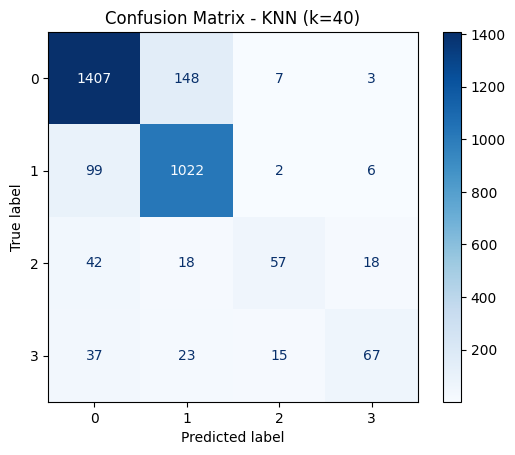

In [69]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues")
plt.title(f"Confusion Matrix - KNN (k={best_k})")
plt.show()

The confusion matrix shows strong diagonal values for classes 1 and 2, confirming that KNN performs well on the majority classes. For classes 3 and 4, the model captures a meaningful portion of the true cases but still exhibits substantial misclassification, particularly toward class 2. This pattern reflects the limitations of distance‑based methods in high‑dimensional spaces and the overlapping nature of the high‑delay classes.

KNN provides a solid nonlinear baseline, outperforming linear models on the minority classes while remaining less effective than Random Forest. The model captures local structure in the data and achieves balanced performance across classes, but its ability to distinguish between significant and severe delays remains limited. Overall, KNN offers a good compromise between simplicity and predictive power, though more advanced ensemble methods deliver superior results.

####  Gradient Boosting

Gradient Boosting builds an additive ensemble of shallow trees sequentially, each new tree corrects the residual errors of the current ensemble. Compared to Random Forest, which averages parallel trees, the construction is sequential and error-correcting,

In [27]:
gb_clf = ImbPipeline([
    ("preprocess", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)), 
    ("model", HistGradientBoostingClassifier(max_iter=1000)) 
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#cv_acc = cross_val_score(gb_clf, X, y_class, cv=skf, scoring="accuracy", error_score='raise')
cv_acc = cross_val_score(gb_clf, X, y_class, cv=skf, scoring="accuracy")
cv_f1m = cross_val_score(gb_clf, X, y_class, cv=skf, scoring="f1_macro")

print(f"CV Accuracy : {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}")
print(f"CV F1-macro : {cv_f1m.mean():.4f} +/- {cv_f1m.std():.4f}")

gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

print("\nTest metrics:")
print("Accuracy     :", accuracy_score(y_test, y_pred_gb))
print("F1 (weighted):", f1_score(y_test, y_pred_gb, average='weighted'))
print("F1 (macro)   :", f1_score(y_test, y_pred_gb, average='macro'))
print("\n", classification_report(y_test, y_pred_gb, target_names=["C1","C2","C3","C4"]))


CV Accuracy : 0.9768 +/- 0.0013
CV F1-macro : 0.9317 +/- 0.0111

Test metrics:
Accuracy     : 0.980477953550993
F1 (weighted): 0.9805872541249091
F1 (macro)   : 0.9419121024737106

               precision    recall  f1-score   support

          C1       0.99      0.99      0.99      1565
          C2       0.99      0.98      0.99      1129
          C3       0.87      0.90      0.89       135
          C4       0.90      0.91      0.90       142

    accuracy                           0.98      2971
   macro avg       0.94      0.95      0.94      2971
weighted avg       0.98      0.98      0.98      2971



Class 1 : Low delays  

Gradient Boosting performs strongly on this class, with a recall of 0.99 and an F1‑score of 0.99. The model correctly identifies most low‑delay events, nearly no confusion with other classes is made.

Class 2 : Moderate delays  

This class is also well predicted, with a recall of 0.98 and an F1‑score of 0.99. Gradient boosting effectively captures the local patterns associated with moderate delays.

Class 3 : Significant delays  

Performance improves compared to all models, with an F1‑score of 0.89. Although lower than the previous 2 classes, the recall of 0.90 indicates that the model manages to identify a large portion of significant delay events.

Class 4 : Severe delays  

Class 4 shows an F1‑score of 0.90 and a recall of 0.91. It is once agai better than any previously tested model. Once again, these scores are lower than the first 2 classes, reflecting the difficulty of separating these minority classes.

#### Conclusion

Among all tested models, although Random Forest had a great performance, Gradient boosting significantly outperformed all of them by far, both in terms of cross‑validation stability and test‑set accuracy. It significantly outperforms linear models and KNN on all classes, both recurrent and misrepresented one. Regarding Random forest, its performance is quite comparable for the first two classes but Gradient Boosting significantly improves its detection of class 3 and 4. 

Overall, Random Forest is still a good performing solution that manages to capture an idea of the dynamics in the delays but still has some issues understand the hidden reasons of the kess common classes. KNN offers a good intermediate solution, improving over linear models but remaining below ensemble performance. Logistic Regression and LDA provide acceptable baselines but are limited by their linear assumptions and sensitivity to class imbalance.

Gradient boosting is the most suitable classifier for this dataset and should be selected as the final model.

#### Hyper parameter tuning for Gradient Boosting

We decide to perform hyper parameter tuning on our best performing model, gradient boosting, in order to make sure all the parameters are optimized. We optimize on the following hyperparameters:
- learning rate - it shrinks each tree's contirbution, a lower learning rate is better for generalisation but needs more trees
- max iteration - number of boosting rounds, trees. It is a trade off witht he learning rate
- max depth - maximum depth of each tree, it implies more capacity but risks overfitting
- min sample leafs - the minimum samples in each leaf, a larger number implies smoother and more regularized trees
- l2 reguralization - L2 weight penalty on leaf values which reduces overfitting

TO explore these parameterds we use RandomizedSearchCV instead of GridSearchCV because it has a lower cost. With 40 iterations and 5 folds, we run only 200 fits which is significantly less than the thousands we would have ran with GridSearchCV.

We optimise for macro F1, the metric that weights all 4 delay classes equally, penalising minority class failures as strongly as majority class failures.

In [33]:

param_dist = {
    "model__learning_rate"     : ss.loguniform(0.01, 0.3),
    "model__max_iter"          : [100, 200, 300, 500],
    "model__max_depth"         : [3, 4, 5, 6, None],
    "model__min_samples_leaf"  : [10, 20, 30, 50],
    "model__l2_regularization" : ss.loguniform(1e-3, 10),
    "model__max_features"      : [0.6, 0.8, 1.0],
}

gb_search_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=42
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rscv = RandomizedSearchCV(
    gb_search_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

rscv.fit(X_train, y_train)

print(f"\nBest CV F1-macro: {rscv.best_score_:.4f}")
print("Best parameters:")
for k, v in rscv.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV F1-macro: 0.9376
Best parameters:
  model__l2_regularization: 0.030427972059571335
  model__learning_rate: 0.09726568066784747
  model__max_depth: None
  model__max_features: 1.0
  model__max_iter: 500
  model__min_samples_leaf: 50


Best Gradient Boosting Test Results
Accuracy     : 0.9818
F1 (weighted): 0.9819
F1 (macro)   : 0.9481

              precision    recall  f1-score   support

          C1       0.99      1.00      0.99      1565
          C2       1.00      0.98      0.99      1129
          C3       0.86      0.94      0.90       135
          C4       0.94      0.89      0.91       142

    accuracy                           0.98      2971
   macro avg       0.95      0.95      0.95      2971
weighted avg       0.98      0.98      0.98      2971



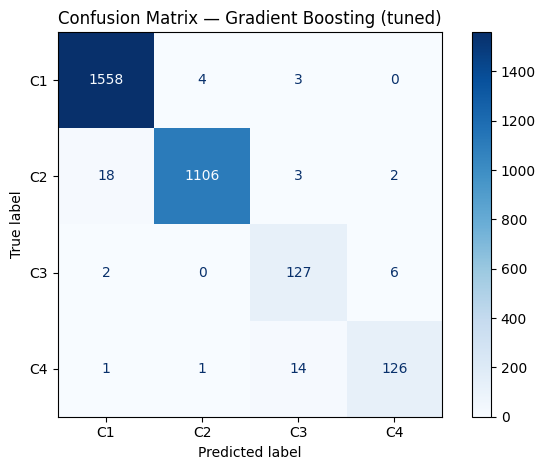

In [35]:
#Evaluate tuned Gradient Boosting
best_gb = rscv.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)

print("Best Gradient Boosting Test Results")
print(f"Accuracy     : {accuracy_score(y_test, y_pred_best_gb):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_best_gb, average='weighted'):.4f}")
print(f"F1 (macro)   : {f1_score(y_test, y_pred_best_gb, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_best_gb, target_names=["C1","C2","C3","C4"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best_gb),
                       display_labels=["C1","C2","C3","C4"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Gradient Boosting (tuned)")
plt.tight_layout(); plt.show()


Class 1 : Low delays  

Gradient Boosting performs strongly on this class, with a recall of 1 and an F1‑score of 0.99. The model correctly identifies nearly all low‑delay events, nearly no confusion with other classes is made.

Class 2 : Moderate delays  

This class is also well predicted, with a recall of 0.98 and an F1‑score of 0.99. It effectively captures the local patterns associated with moderate delays.

Class 3 : Significant delays  

Performance improves compared to all models, with an F1‑score of 0.90. Although lower than the previous 2 classes, the recall of 0.94 indicates that the model manages to identify a large portion of significant delay events.

Class 4 : Severe delays  

Class 4 shows an F1‑score of 0.91 and a recall of 0.89. It is once again better than any previously tested model. Once again, these scores are lower than the first 2 classes, reflecting the difficulty of separating these minority classes.

The confusion matrix shows strong diagonal values for all classes, confirming that Gradient boosting performs well on the majority classes. For classes 3 and 4, the model captures a meaningful portion of the true cases but still exhibits higher misclassification than the other two classes, particularly between themselves. This highlights that high delays can now be identified but the difference between them is still hard to delimitate.

### Regression

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

#### Linear regression

In [71]:
# Pipeline 
linreg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

In [72]:
# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(linreg,X_train,y_train,scoring="neg_mean_squared_error",cv=kf,n_jobs=-1)

cv_rmse = np.sqrt(-cv_scores) ## RMSE for each fold


In [73]:
print("RMSE per fold:", cv_rmse)
print("Mean RMSE:", cv_rmse.mean())
print("Std RMSE :", cv_rmse.std())

RMSE per fold: [11.20415015 12.5528106  10.46195488 10.67641767  9.92996049]
Mean RMSE: 10.965058757450945
Std RMSE : 0.892857908270198


On average, the model makes an error of about 11 minutes when predicting train delays.
This indicates that the linear model captures only part of the underlying structure.
The model is stable across folds. (low standard deviation)
Its performance does not depend heavily on how the data is split.
Even though the model is stable, the error level is relatively high.
This suggests that the relationship between features and delay is not purely linear.

In [74]:
# Train 
linreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [75]:
# predict
y_pred = linreg.predict(X_test)

In [76]:
# scores
mae = mean_absolute_error(y_test, y_pred) ## mean absolute error
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) ## root mean squared error
r2 = r2_score(y_test, y_pred) ## R² score

In [77]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 5.807430025068357
RMSE: 11.504836270263676
R2  : 0.2561126640865602


On average, predictions are off by 5 to 6 minutes. This is acceptable but not highly accurate. 
Large errors have a strong impact on RMSE.
This confirms that the model struggles with larger delays.
The model explains only 25% of the variance in train delays.
This is a clear sign that Linear Regression is too simple for this dataset.



In [78]:
# residuals
residuals = y_test - y_pred

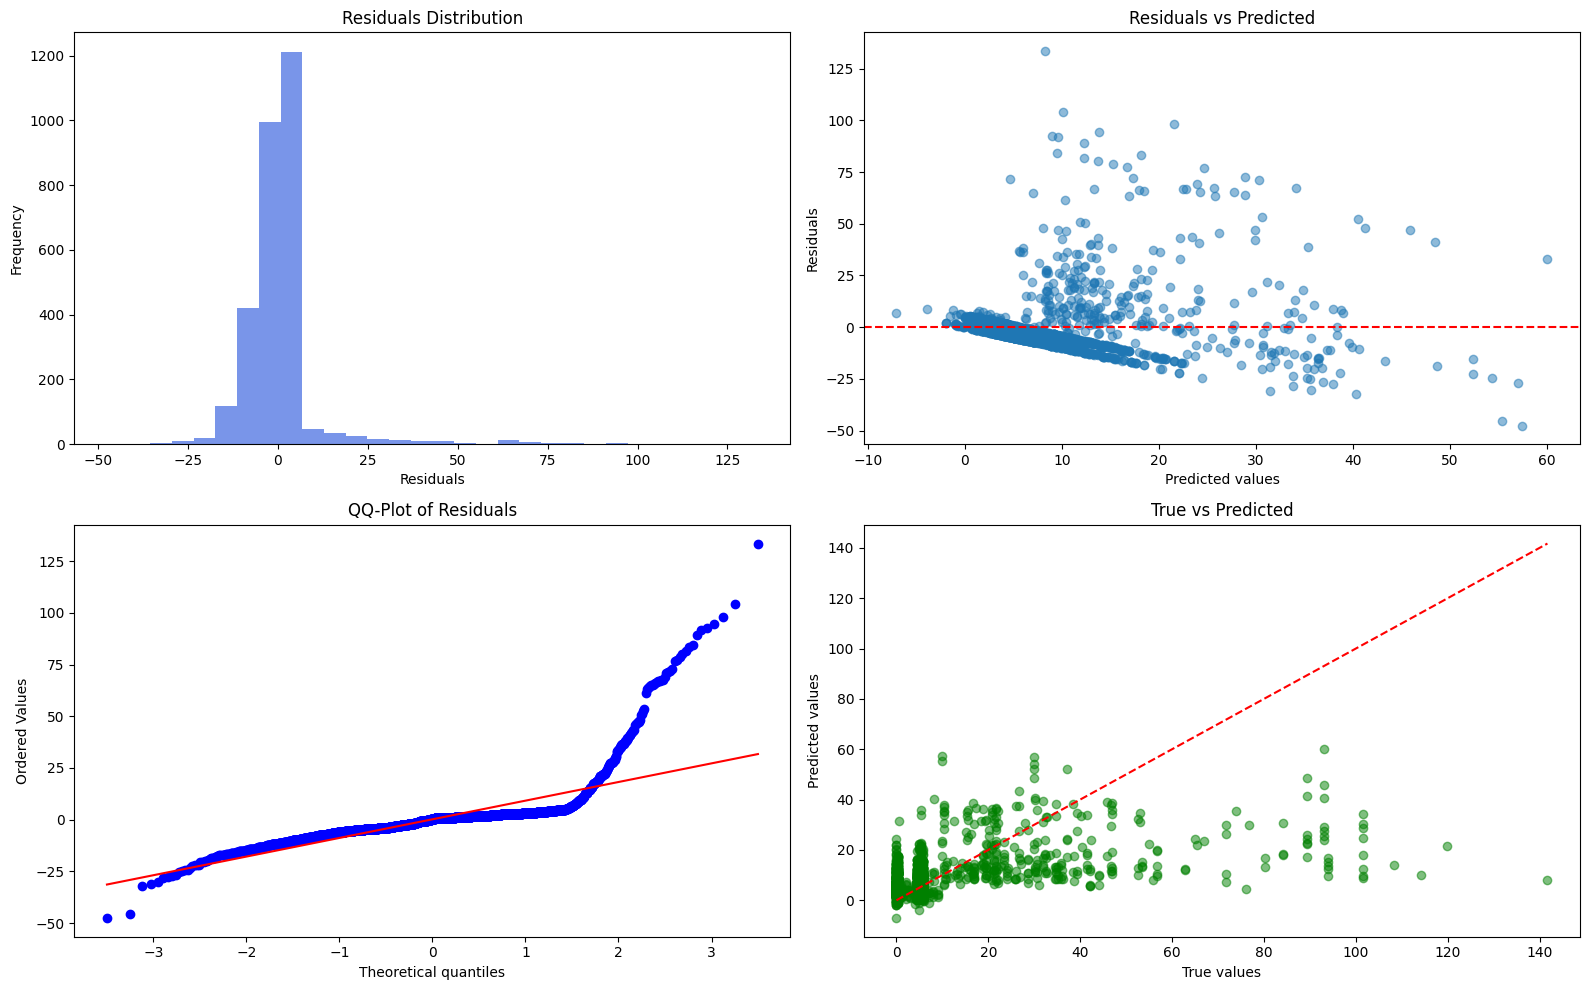

In [79]:
plt.figure(figsize=(16,10))

#  Histogram of residuals
plt.subplot(2,2,1)
plt.hist(residuals, bins=30, color="royalblue", alpha=0.7)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

#  Residuals vs Predicted
plt.subplot(2,2,2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")

#  QQ-plot to check normality of residuals
plt.subplot(2,2,3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")

# True vs Predicted
plt.subplot(2,2,4)
plt.scatter(y_test, y_pred, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("True vs Predicted")
plt.xlabel("True values")
plt.ylabel("Predicted values")

plt.tight_layout()
plt.show()


**Residuals Distribution** : The model tends to underestimate large delays.
Residuals are not normally distributed, which violates one of the assumptions of Linear Regression.

**Residuals vs Predicted** : The scatter plot shows:
- points scattered around zero
- increasing spread for larger predicted values

There is evidence of heteroscedasticity:
errors grow as predicted delay increases.

This means the model performs worse on larger delays and does not fully capture the underlying patterns

**QQ-plot of residuals** : The QQ‑plot shows:
- points aligned with the diagonal in the center
- strong deviations in the tails

Residuals are not normally distributed, especially for extreme values.
This confirms that the linear model does not model the extremes well.

**True vs Predicted** : The scatter plot shows:
- points roughly aligned with the diagonal
- but with large dispersion
- systematic under‑prediction for high true values

The model captures the general trend but lacks precision.
It struggles with high‑delay situations, which are the most important in practice.



Linear Regression provides a stable but weak baseline.
With an RMSE around 11 minutes and an R² of only 0.25, the model explains a limited portion of the delay variability.
Diagnostic plots reveal non‑normal residuals, heteroscedasticity, and systematic under‑prediction of large delays.
These results indicate that the relationship between features and delay is non‑linear, and more flexible models such as Polynomial Regression or Random Forest are required to achieve better performance.

#### polynomial regression

In [62]:
p= 2

In [63]:
poly = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=p, include_bias=False)),
    ("linreg", LinearRegression())
])

In [64]:
# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(poly,X_train,y_train,scoring="neg_mean_squared_error",cv=kf,n_jobs=-1)

cv_rmse = np.sqrt(-cv_scores) ## RMSE for each fold

In [65]:
print("RMSE per fold:", cv_rmse)
print("Mean RMSE:", cv_rmse.mean())
print("Std RMSE :", cv_rmse.std())

RMSE per fold: [10.0022362  11.65687932 10.55645707  9.98643014  9.82958975]
Mean RMSE: 10.40631849695794
Std RMSE : 0.6721084336810814


The Mean RMSE of 10.41 indicates that, on average, the model makes an error of about 10.41 minutes when estimating the delays. This suggests that  Polynomial Regression captures a some portion of the data's structure, but there is still a notable margin of error.

The Std RMSE of 0.67 confirms that the model is highly stable across different data folds; the performance does not depend heavily on how the data is split, as the error remains consistent during cross-validation. However, despite this stability, the mean error remains relatively high compared to the range of the target. This indicates that while the model is somewhat reliable, the relationship between the features and the target is more complex than a degree-2 polynomial can fully explain. Performing polynomial regression on degree p $\geq$ 3 does not run on our machines due to the exponential increase of time and our large number of one hot encoded features.

In [66]:
# train
poly.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
# predict 
y_pred = poly.predict(X_test)

In [68]:
## scores 
mae_poly = mean_absolute_error(y_test, y_pred)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred))
r2_poly = r2_score(y_test, y_pred)

In [69]:
print("MAE :", mae_poly)
print("RMSE:", rmse_poly)
print("R2  :", r2_poly)

MAE : 4.691250638414902
RMSE: 10.174141118216248
R2  : 0.4182427629214269


In [70]:
## residuals
residuals = y_test - y_pred

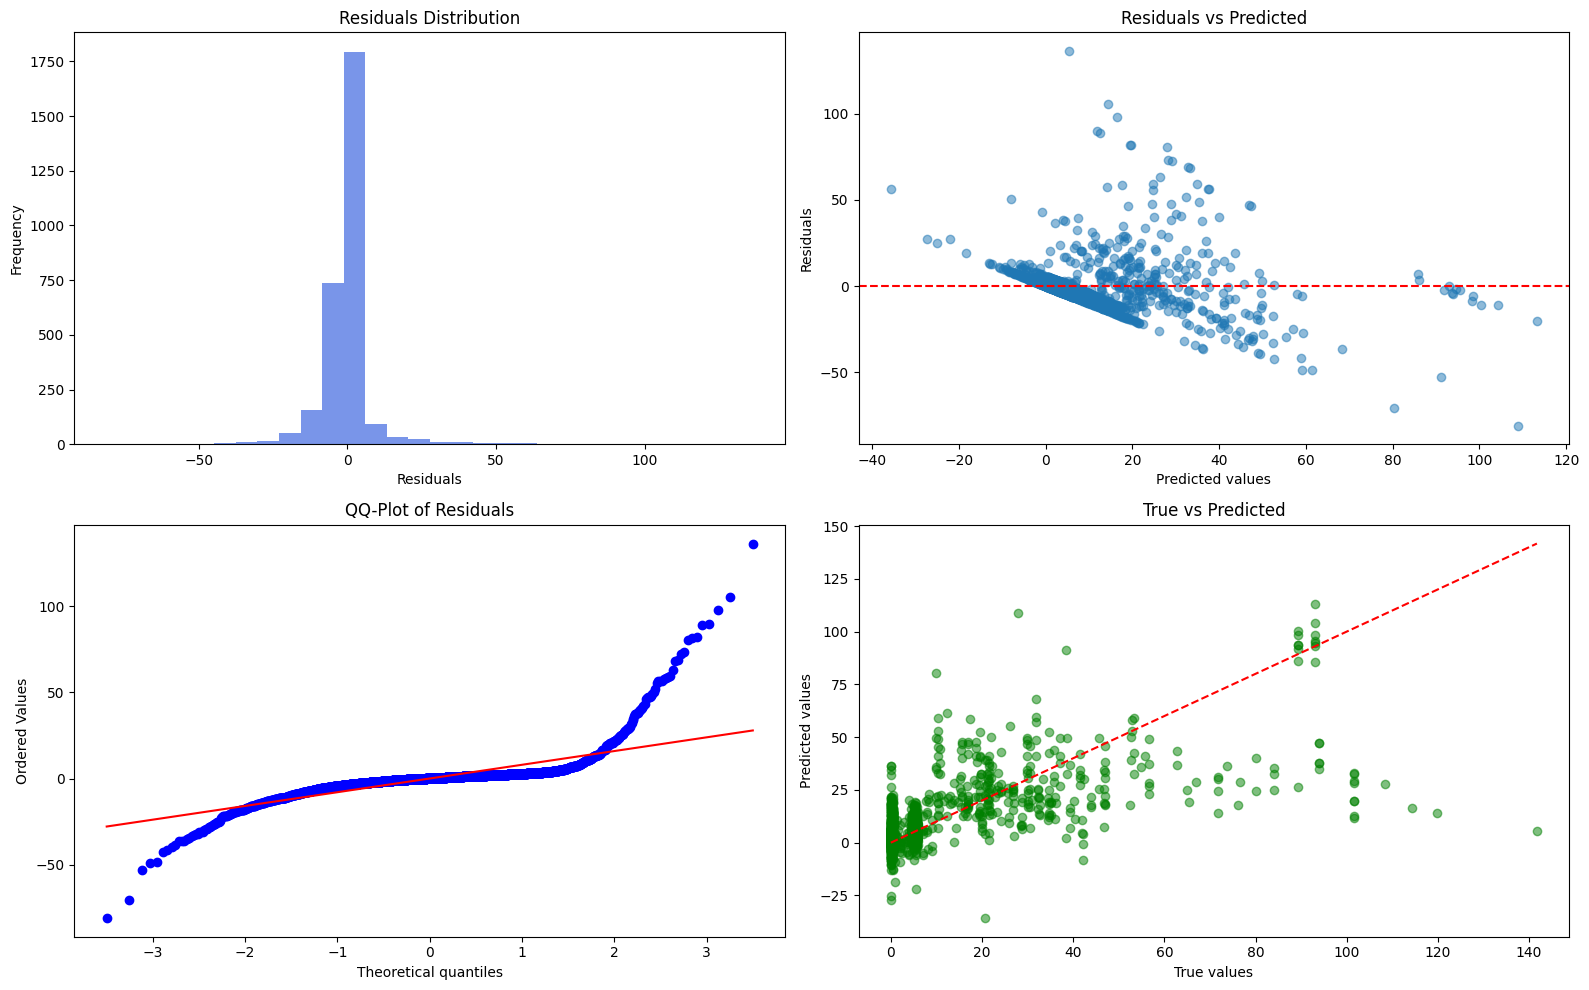

In [71]:
plt.figure(figsize=(16,10))

# Histogram of residuals
plt.subplot(2,2,1)
plt.hist(residuals, bins=30, color="royalblue", alpha=0.7)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

#  Residuals vs Predicted
plt.subplot(2,2,2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")

#  QQ-plot
plt.subplot(2,2,3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")

#  True vs Predicted
plt.subplot(2,2,4)
plt.scatter(y_test, y_pred, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("True vs Predicted")
plt.xlabel("True values")
plt.ylabel("Predicted values")

plt.tight_layout()
plt.show()

- Residual distribution: The residuals are tightly peaked around zero, indicating that the model is unbiased for the majority of the data. However, there is a very long positive tail extending beyond 100, which confirms that the model significantly under-predicts a small number of high-value observations.

- Residuals vs. predicted values: The scatterplot shows a distinct "funnel" or "triangular" shape, indicating heteroscedasticity. The error variance increases as the predicted values move toward the middle of the range, and there is a clear downward-sloping boundary on the lower side of the residuals, suggesting the model is constrained by a lower limit, 0 in the target variable.

- QQ‑plot: The residuals show an "S-shaped" deviation from the red line. The steep upward curve at the right end indicates heavy tails (specifically positive outliers), meaning the model’s errors at the higher end are much larger than what would be expected from a normal distribution. This suggests that a standard linear approach might not be sufficient to capture the extremes of the data.

- True vs. predicted values: While many points follow the dashed 1:1 line at lower values, the model struggles as the true values increase. There is a noticeable "horizontal" spread for higher true values, where the model consistently predicts lower values than reality, and even some predictions that fall below zero despite the true values being positive.

#### Random forest regressor

In [83]:
# Pipeline 
rfr = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

In [84]:
# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rfr,X_train,y_train,scoring="neg_mean_squared_error",cv=kf,n_jobs=-1)

cv_rmse = np.sqrt(-cv_scores) ## RMSE for each fold

In [85]:
print("RMSE per fold:", cv_rmse)
print("Mean RMSE:", cv_rmse.mean())
print("Std RMSE :", cv_rmse.std())

RMSE per fold: [5.85964429 7.85398101 5.57034166 5.28469925 5.12186428]
Mean RMSE: 5.938106097361865
Std RMSE : 0.9904720909391209


The Random Forest regressor achieves a mean RMSE of 5.94 across folds, with a relatively low standard deviation (0.99), indicating stable performance and limited sensitivity to data splits. This consistency suggests that the model generalizes well and is not overfitting to specific subsets of the data.

In [86]:
# Train 
rfr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [87]:
# predict
y_pred = rfr.predict(X_test)

In [88]:
# scores
mae = mean_absolute_error(y_test, y_pred) ## mean absolute error
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) ## root mean squared error
r2 = r2_score(y_test, y_pred) ## R² score

In [89]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.1360426853863888
RMSE: 5.844727277112486
R2  : 0.8080116912878028


The test‑set RMSE of 5.84 confirms the strong predictive accuracy observed during cross‑validation. The MAE of 1.14 indicates that, on average, the model’s predictions deviate from the true values by just over one unit, which is relatively low given the scale of the target variable. The R² score of 0.81 shows that the model explains more than 80% of the variance in the target, demonstrating excellent overall performance.

In [90]:
# residuals
residuals = y_test - y_pred

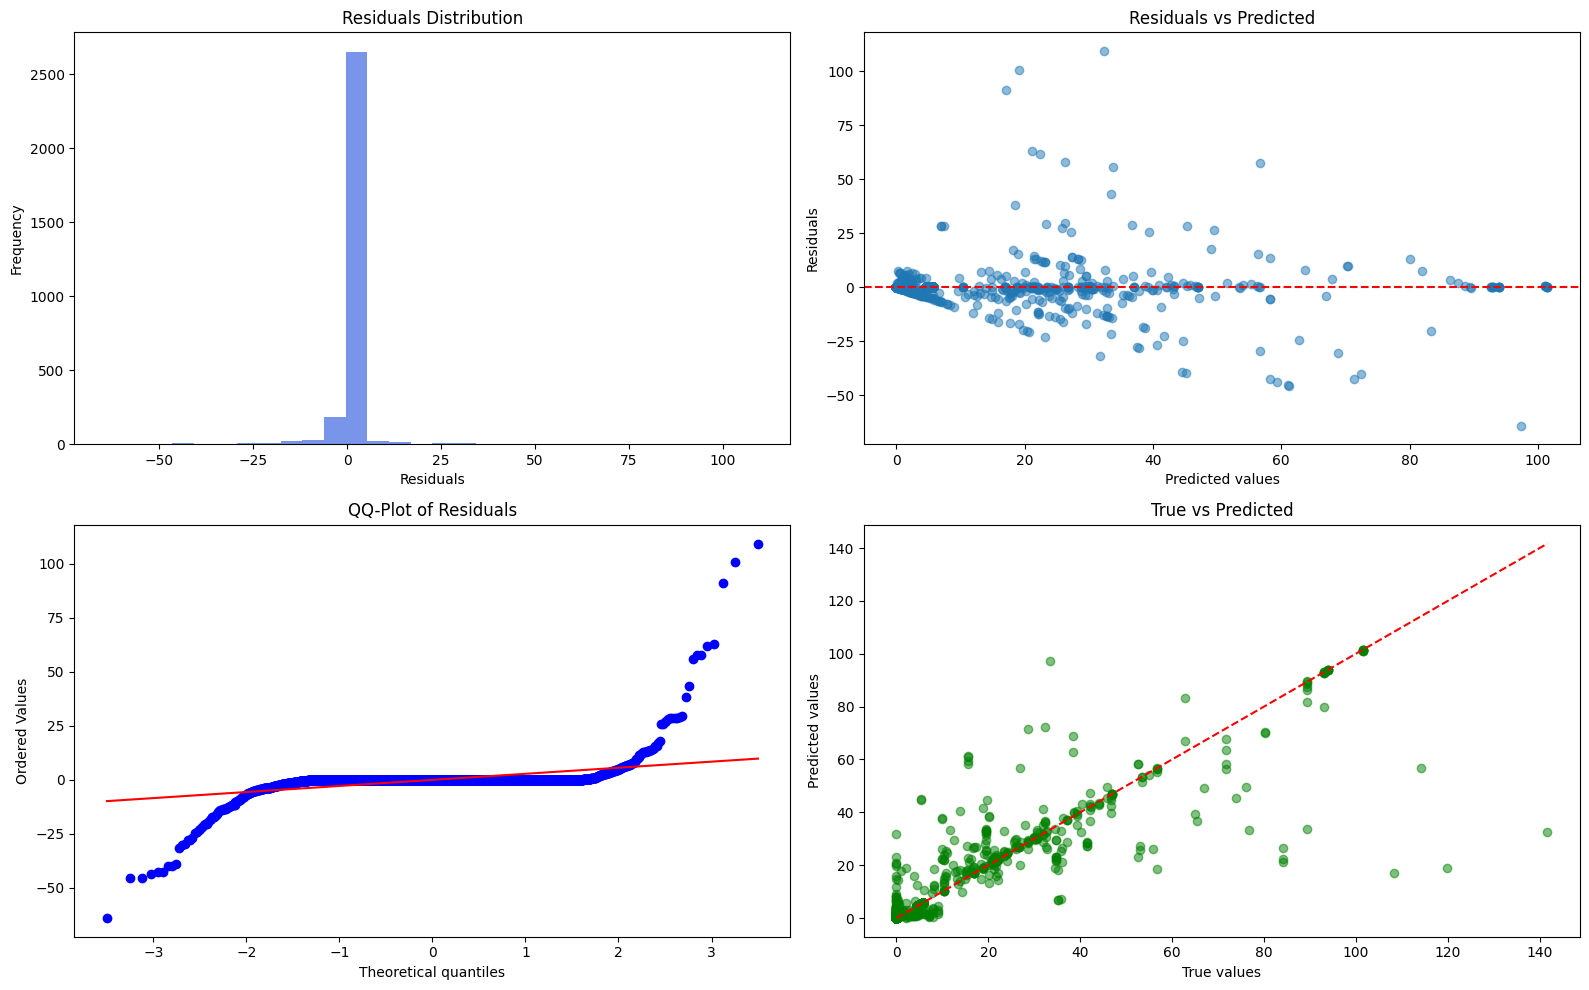

In [91]:
plt.figure(figsize=(16,10))

#  Histogram of residuals
plt.subplot(2,2,1)
plt.hist(residuals, bins=30, color="royalblue", alpha=0.7)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

#  Residuals vs Predicted
plt.subplot(2,2,2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")

#  QQ-plot to check normality of residuals
plt.subplot(2,2,3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")

# True vs Predicted
plt.subplot(2,2,4)
plt.scatter(y_test, y_pred, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("True vs Predicted")
plt.xlabel("True values")
plt.ylabel("Predicted values")

plt.tight_layout()
plt.show()


- Residual distribution
Residuals are centered around zero, indicating that the model is unbiased and does not systematically over‑ or under‑predict.

- Residuals vs. predicted values
The scatterplot shows no strong pattern, suggesting that the model captures the main structure of the data and that heteroscedasticity is limited.

- QQ‑plot
The residuals deviate from the theoretical normal line at the tails, which is expected for tree‑based models and does not invalidate the model. Random Forests do not assume normality, so this deviation is not problematic.

- True vs. predicted values
The points align closely with the 1:1 line, confirming that the model produces accurate predictions across the full range of target values.

### Clustering

**PCA**

In [92]:
## preprocessing for PCA and clustering
X_pca = preprocessor.fit_transform(X)   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

In [93]:
## pca with 2 components for visualization
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

In [94]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.03327197 0.02359784]
Total variance explained: 0.05686980555107092


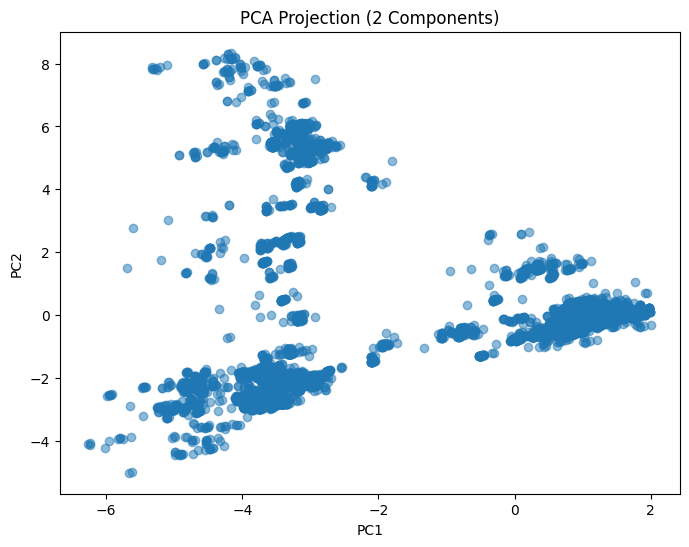

In [95]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2 Components)")
plt.show()

The first two principal components explain only 5.69% of the total variance, indicating that the dataset is highly multidimensional and cannot be easily represented in two dimensions. Despite the low explained variance, PCA remains useful for visualization and for preparing the data for clustering. The PCA scatter plot shows no strong natural separation between samples, suggesting that the classes are not linearly separable in low‑dimensional space. This motivates the use of clustering algorithms (K‑Means, Hierarchical) to explore whether any hidden structure exists in the data.

**K-means**

Since the dataset contains 4 true classes, setting k = 4 in K‑Means allows us to check whether the natural structure of the data aligns with the supervised labels.

In [96]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_k4 = kmeans.fit_predict(X_scaled)

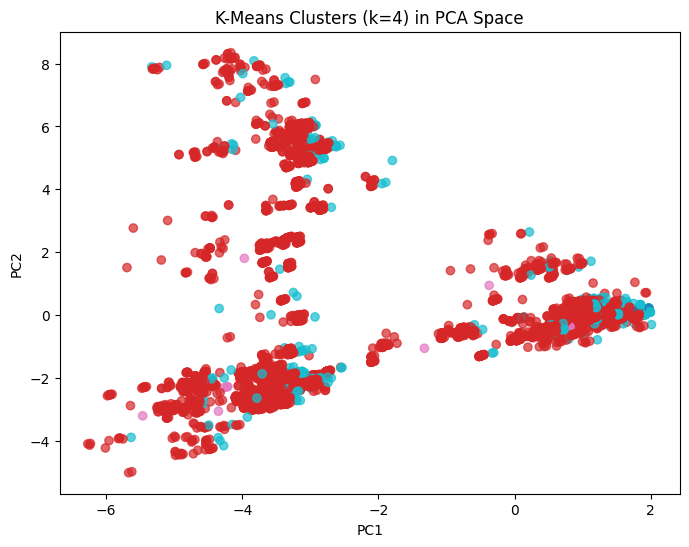

In [97]:
#  PCA visualization
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=clusters_k4, cmap="tab10", alpha=0.7)
plt.title("K-Means Clusters (k=4) in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

From this plot :
- The clusters are not clearly separated in PCA space
- There is significant overlap between the groups
- Some clusters appear elongated or irregular, which is typical when PCA explains little variance
- The PCA projection only explains 5.69% of the total variance, so the 2D visualization cannot fully represent the true structure

The dataset does not naturally form four well‑separated geometric clusters.
This suggests that the true classes are not defined by simple Euclidean distance, which is exactly what K‑Means uses.

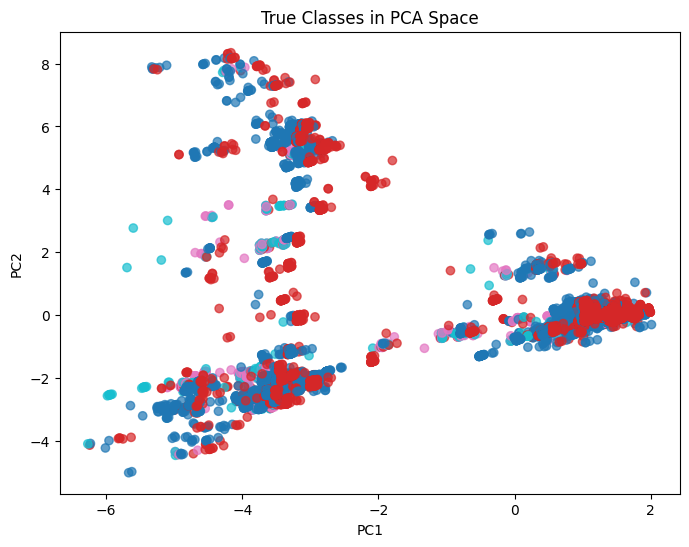

In [98]:
#  PCA with true labels
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y_class, cmap="tab10", alpha=0.7)
plt.title("True Classes in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

This plot shows that : 
- The true classes also overlap heavily
- No class forms a clean, isolated region
- The PCA projection does not reveal strong separability

The true labels are not linearly separable in low‑dimensional space.

In [99]:
# Shift clusters from 0-3 to 1-4 so they match the True Labels
clusters_k4_shifted = clusters_k4 + 1

# create the matrix using the shifted labels
cm = confusion_matrix(y_class, clusters_k4_shifted, labels=[1, 2, 3, 4])

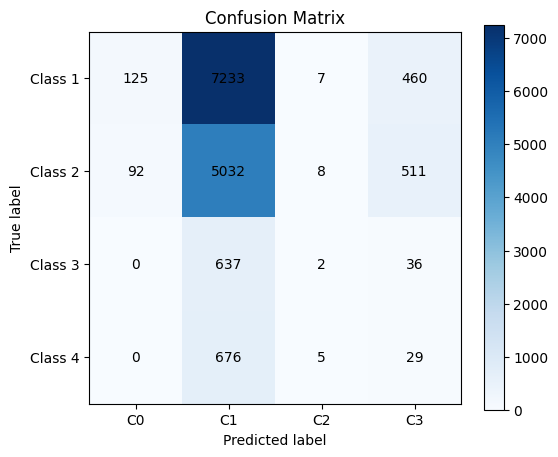

In [100]:
class_names = ["Class 1", "Class 2", "Class 3", "Class 4"]  

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(4), ["C0", "C1", "C2", "C3"]) # Labels for clarity
plt.yticks(np.arange(len(class_names)), class_names)
# Add numbers inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.show()

the confusion matrix confirms that the clusters do not correspond to the supervised labels.

This indicates that the dataset does not contain four natural geometric clusters, and the true classes are not defined by simple Euclidean distance.

K‑Means is therefore not suitable for reproducing the true labels, but it remains useful as an exploratory tool to understand the structure and complexity of the data.

**Hierachical clustering**

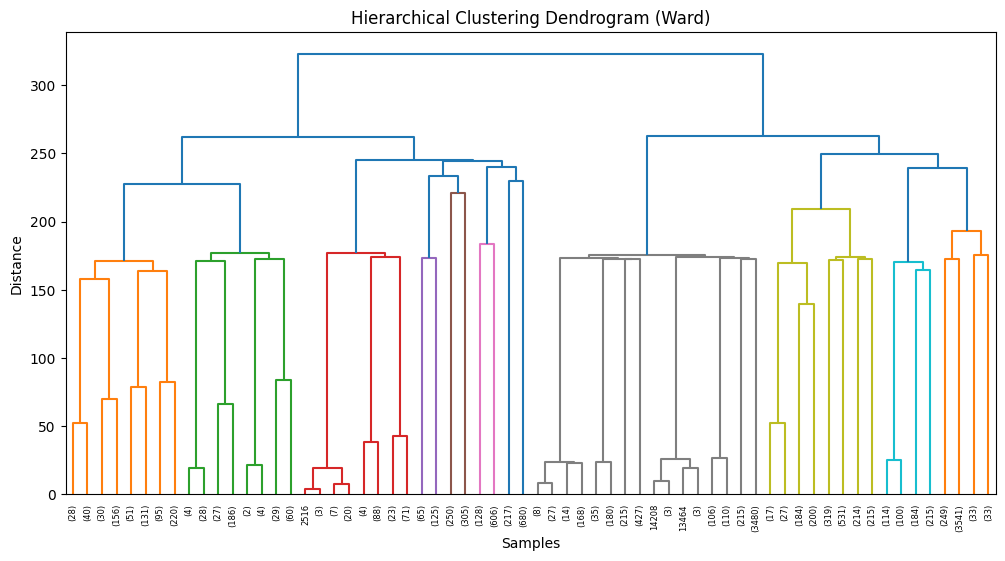

In [101]:
## Dendrogram for hierarchical clustering
# we use ward method which minimizes the variance of clusters being merged. It tends to create more balanced clusters and is less sensitive to outliers compared to other methods like single or complete linkage.
plt.figure(figsize=(12, 6))
Z = linkage(X_scaled, method='ward')  # X_scaled = standardized data after preprocessing
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

Hierarchical clustering using Ward’s linkage does not reveal strong or well‑defined cluster structure in the dataset. The dendrogram shows that most samples merge at very low distances, and there are no large vertical jumps that would indicate the presence of distinct, naturally separated groups. This suggests that the data points are highly intermixed and do not form clear hierarchical partitions. When projecting the hierarchical clusters onto the PCA space, the clusters overlap significantly, and no cluster occupies a distinct region. This confirms that hierarchical clustering does not identify meaningful or well‑separated groups in the data, which is consistent with the low variance explained by the first two principal components.

In [102]:
# agglomeratuve clustering : should give similar clusters to kmeans if we cut the dendrogram at the right level
hclust = AgglomerativeClustering(
    n_clusters=4,        # same as the true number of classes
    linkage='ward'
)

clusters_hier = hclust.fit_predict(X_scaled)

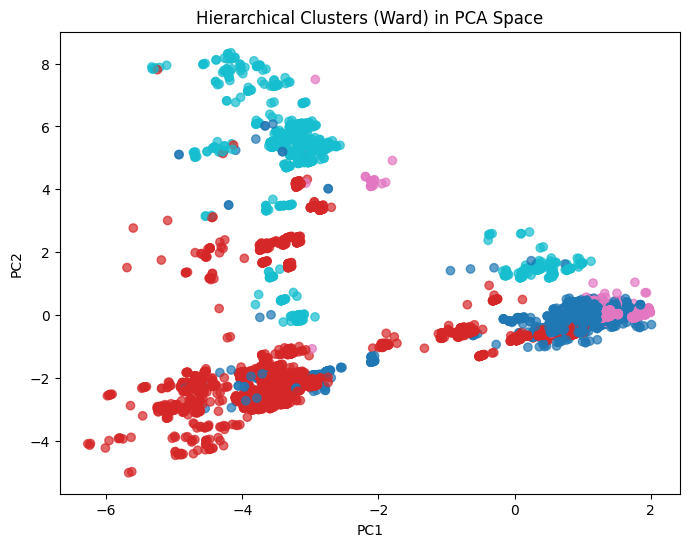

In [103]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=clusters_hier,
    cmap="tab10",
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters (Ward) in PCA Space")
plt.show()

Both K‑Means (k = 4) and Hierarchical Clustering lead to similar conclusions: the dataset does not contain four natural geometric clusters. K‑Means assigns the majority of samples to a single cluster, and the remaining clusters contain very few points, indicating that the algorithm is forcing a structure that does not exist. Hierarchical clustering shows the same pattern, with clusters overlapping heavily in PCA space and no clear separation between groups. The agreement between the two methods reinforces the idea that the underlying structure of the data is complex and not easily captured by distance‑based clustering algorithms. This also explains why the clusters do not align with the true supervised classes.

In [104]:
# Shift 0,1,2,3 to 1,2,3,4
clusters_hier_shifted = clusters_hier + 1

# Now the labels [1,2,3,4] will catch all clusters
cm_hier = confusion_matrix(y_class, clusters_hier_shifted, labels=[1, 2, 3, 4])

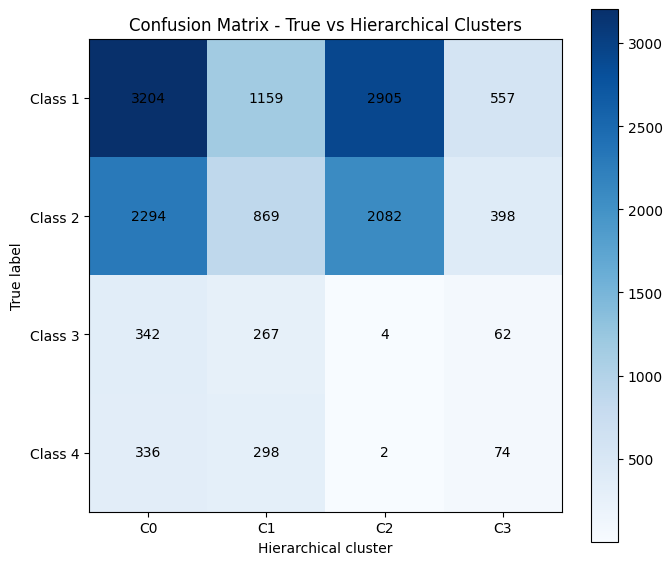

In [105]:

class_names = ["Class 1", "Class 2", "Class 3", "Class 4"]  
plt.figure(figsize=(7, 6))
plt.imshow(cm_hier, cmap="Blues")
plt.title("Confusion Matrix - True vs Hierarchical Clusters")
plt.xlabel("Hierarchical cluster")
plt.ylabel("True label")

plt.xticks(np.arange(len(class_names)), [f"C{i}" for i in range(len(class_names))])
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm_hier.shape[0]):
    for j in range(cm_hier.shape[1]):
        plt.text(j, i, cm_hier[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

The confusion matrix shows that the clusters produced by hierarchical clustering do not align with the true supervised labels. Each true class is spread across multiple clusters, and no cluster corresponds predominantly to a single class. This indicates that the dataset does not naturally form four well‑separated hierarchical groups.

The true classes therefore do not reflect simple hierarchical or distance‑based structure in the feature space. As a result, hierarchical clustering is not suitable for reproducing the supervised labels.

However, hierarchical clustering remains valuable as an exploratory tool: it reveals the internal structure of the data, highlights overlaps between classes, and confirms the complexity of the classification task.

Overall, the unsupervised learning analysis shows that the dataset does not exhibit strong natural clustering structure. PCA reveals that the first two components explain only 5.69% of the variance, making it difficult to visualize meaningful separation in low‑dimensional space. Both K‑Means and Hierarchical Clustering produce overlapping clusters that do not correspond to the true classes, and the dendrogram confirms the absence of clear hierarchical boundaries. These results highlight the complexity of the dataset and justify the need for advanced supervised learning models to achieve good predictive performance. Unsupervised methods remain valuable for exploratory analysis, but they do not uncover the class structure present in the labels